# TrustOCT — Notebook 3 / Account 3: Full Evaluation & Figures

Use this notebook on **Google Colab Account 3** (or any session) to perform the complete evaluation.
**Zero training required!** It loads EXP001 & EXP003 results directly from Google Drive and generates all figures, tables, and reports in **1–2 minutes**.

### Workflow & Features Included:
1. **Load Results**: Loads EXP001 and EXP003 predictions & history from Google Drive
2. **Ablation Table**: Generates multi-metric comparison (Accuracy, Precision, Recall, Specificity, F1, BA, MCC, Kappa, ROC-AUC)
3. **Statistical Tests**: McNemar's paired test & Bootstrap 95% Confidence Intervals
4. **Literature Comparison**: Benchmark against published Kermany OCT papers
5. **Calibration Analysis**: ECE, Brier Score, and Reliability Diagrams
6. **Explainability & Faithfulness**: LayerCAM heatmaps + Deletion/Insertion AOPC curves
7. **Robustness Evaluation**: Noise, blur, brightness, and contrast degradation
8. **Compute Cost Analysis**: Parameter count (M) & Inference latency (ms/img)
9. **Failure Case Gallery**: Qualitative misclassification visualization with LayerCAM overlays
10. **External Validation**: Run evaluation on external dataset stored in Google Drive
11. **Zip & Archive**: Saves `trustoct_results.zip` directly to Google Drive

In [2]:
# Mount Google Drive and locate EXP001 & EXP003 predictions
import os
import glob
import json
import numpy as np
import torch
from google.colab import drive

drive.mount('/content/drive')

def find_file(filename):
    patterns = [
        f'/content/drive/MyDrive/TrustOCT_Outputs/{filename}',
        f'/content/drive/MyDrive/TrustOCT_Outputs/results/{filename}',
        f'/content/drive/MyDrive/TrustOCT_Outputs/checkpoints/{filename}',
        f'/content/drive/MyDrive/TrustOCT_Results/{filename}',
        f'/content/drive/MyDrive/TrustOCT_Results/results/{filename}',
        f'/content/drive/MyDrive/TrustOCT_Results/checkpoints/{filename}',
        f'/content/drive/MyDrive/**/{filename}',
        f'/content/drive/.shortcut-targets-by-id/**/{filename}',
        f'/content/drive/**/{filename}',
    ]
    for p in patterns:
        matches = glob.glob(p, recursive=True)
        if matches:
            return matches[0]
    return None

p001 = find_file('exp001_predictions.npz')
p003 = find_file('exp003_predictions.npz')
h001 = find_file('history_exp001.json')
h003 = find_file('history_exp003.json')
ckpt003 = find_file('EXP003_resnet50_msf_cbam_best.pt')

if not p001 or not p003:
    raise FileNotFoundError('Could not find exp001_predictions.npz or exp003_predictions.npz in Google Drive. Make sure Account 1 & Account 2 have finished training!')

DRIVE_DIR = os.path.dirname(os.path.dirname(p001)) if 'results' in os.path.dirname(p001) else os.path.dirname(p001)

d001, d003 = np.load(p001), np.load(p003)
y_true_exp001, y_pred_exp001, y_prob_exp001 = d001['y_true'], d001['y_pred'], d001['y_prob']
y_true_exp003, y_pred_exp003, y_prob_exp003 = d003['y_true'], d003['y_pred'], d003['y_prob']

history_exp001 = json.load(open(h001)) if h001 else {}
history_exp003 = json.load(open(h003)) if h003 else {}

print(f'✅ Successfully loaded EXP001 predictions from: {p001}')
print(f'✅ Successfully loaded EXP003 predictions from: {p003}')


Mounted at /content/drive
✅ Successfully loaded EXP001 predictions from: /content/drive/MyDrive/TrustOCT_Results/exp001_predictions.npz
✅ Successfully loaded EXP003 predictions from: /content/drive/MyDrive/TrustOCT_Results/exp003_predictions.npz


## 1. Environment setup

In [3]:
!pip install -q kagglehub opencv-python-headless
import torch
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: no GPU detected — go to Runtime > Change runtime type > GPU before training.")


PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


### 1.1 Kaggle authentication
Two options:
- **Upload `kaggle.json`** (from kaggle.com → Account → Create New API Token) using the file picker below, OR
- Skip the upload cell and instead set Colab secrets `KAGGLE_USERNAME` / `KAGGLE_KEY` (key icon in the left sidebar) — kagglehub will pick them up automatically.


In [4]:
import os
# Option A: upload kaggle.json interactively (skip this cell if using Colab secrets instead)
try:
    from google.colab import files
    if not os.path.exists(os.path.expanduser("~/.kaggle/kaggle.json")):
        print("Upload your kaggle.json (Kaggle account -> Create New API Token):")
        uploaded = files.upload()
        os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
        for fname in uploaded:
            os.rename(fname, os.path.expanduser("~/.kaggle/kaggle.json"))
        os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)
        print("Saved kaggle.json")
    else:
        print("kaggle.json already present.")
except ImportError:
    print("Not running on Colab — set KAGGLE_USERNAME / KAGGLE_KEY env vars manually.")


Upload your kaggle.json (Kaggle account -> Create New API Token):


Saving kaggle.json to kaggle.json
Saved kaggle.json


## 2. Write the `trustoct` package to disk
This mirrors the exact package structure you should also keep in your GitHub repo / thesis code appendix:
```
trustoct/
  __init__.py
  utils.py            # seeding, checkpointing
  data.py             # Kermany loading, CLAHE, stratified split, Dataset
  modules.py          # CBAM, MSF building blocks
  model.py            # TrustOCTNet (ResNet50 + optional MSF + optional CBAM)
  train.py            # shared training loop for all 3 experiments
  metrics.py          # ablation metrics table
  calibration.py      # ECE, Brier, reliability diagrams
  explainability.py   # LayerCAM + Deletion/Insertion AOPC
  robustness.py       # noise/blur/brightness/contrast perturbation eval
```


In [5]:
import os
os.makedirs('trustoct', exist_ok=True)

In [6]:
%%writefile trustoct/utils.py
"""
trustoct.utils
Reproducibility and misc helpers.
"""
import os
import random
import numpy as np
import torch


def set_seed(seed: int = 42):
    """Fix all relevant seeds. Call this ONCE at the top of every script/notebook cell
    that trains or evaluates a model, so runs are reproducible and defensible in a viva."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)


def get_device():
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")


def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return {"total_params": total, "trainable_params": trainable}


def save_checkpoint(model, optimizer, epoch, best_metric, path):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    torch.save({
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "best_metric": best_metric,
    }, path)


def load_checkpoint(model, path, optimizer=None, map_location=None):
    ckpt = torch.load(path, map_location=map_location)
    model.load_state_dict(ckpt["model_state"])
    if optimizer is not None and "optimizer_state" in ckpt:
        optimizer.load_state_dict(ckpt["optimizer_state"])
    return ckpt.get("epoch", 0), ckpt.get("best_metric", None)


class AverageMeter:
    """Tracks running average of a metric (loss, acc, etc.) within an epoch."""
    def __init__(self):
        self.reset()

    def reset(self):
        self.sum = 0.0
        self.count = 0

    def update(self, val, n=1):
        self.sum += val * n
        self.count += n

    @property
    def avg(self):
        return self.sum / max(self.count, 1)


Writing trustoct/utils.py


In [7]:
%%writefile trustoct/modules.py
"""
trustoct.modules
Architectural building blocks: CBAM (Convolutional Block Attention Module,
Woo et al. 2018) and MSF (Multi-Scale Feature fusion module).
"""
import torch
import torch.nn as nn
import torch.nn.functional as F


# ---------------------------------------------------------------------------
# CBAM
# ---------------------------------------------------------------------------
class ChannelAttention(nn.Module):
    """Squeezes spatial dims via avg+max pool, learns a shared MLP over both,
    sums, sigmoids -> per-channel weight. Tells the network 'which feature maps
    matter', e.g. layer-thickness channels vs texture channels."""

    def __init__(self, in_channels, reduction_ratio=16):
        super().__init__()
        hidden = max(in_channels // reduction_ratio, 8)
        self.mlp = nn.Sequential(
            nn.Linear(in_channels, hidden, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, in_channels, bias=False),
        )
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

    def forward(self, x):
        b, c, _, _ = x.shape
        avg_out = self.mlp(self.avg_pool(x).view(b, c))
        max_out = self.mlp(self.max_pool(x).view(b, c))
        attn = torch.sigmoid(avg_out + max_out).view(b, c, 1, 1)
        return x * attn


class SpatialAttention(nn.Module):
    """Squeezes channel dim via avg+max pool, convolves the 2-channel map with a
    7x7 kernel, sigmoids -> per-pixel weight. Tells the network 'where to look',
    e.g. the retinal layer boundary region rather than background."""

    def __init__(self, kernel_size=7):
        super().__init__()
        padding = kernel_size // 2
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=padding, bias=False)

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        concat = torch.cat([avg_out, max_out], dim=1)
        attn = torch.sigmoid(self.conv(concat))
        return x * attn


class CBAM(nn.Module):
    """Sequential channel-then-spatial attention, as in the original paper.
    Drop-in module: output has identical shape to input."""

    def __init__(self, in_channels, reduction_ratio=16, spatial_kernel_size=7):
        super().__init__()
        self.channel_attn = ChannelAttention(in_channels, reduction_ratio)
        self.spatial_attn = SpatialAttention(spatial_kernel_size)

    def forward(self, x):
        x = self.channel_attn(x)
        x = self.spatial_attn(x)
        return x


# ---------------------------------------------------------------------------
# MSF - Multi-Scale Feature fusion
# ---------------------------------------------------------------------------
class MSFModule(nn.Module):
    """Fuses feature maps from multiple ResNet stages (e.g. layer2, layer3, layer4)
    at a common spatial resolution and channel width, via 1x1 projection + upsample
    + concatenation + 3x3 fusion conv. Motivation for OCT specifically: pathology
    (fluid pockets in DME, neovascular membranes in CNV, drusen deposits) appears at
    very different physical scales in a B-scan, so a single-resolution feature map
    from only the last ResNet stage can miss small/early-stage lesions.
    """

    def __init__(self, in_channels_list, out_channels=256):
        """in_channels_list: channel counts of the feature maps to fuse, ordered from
        shallow -> deep, e.g. [512, 1024, 2048] for ResNet50 layer2/3/4."""
        super().__init__()
        self.projections = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(c, out_channels, kernel_size=1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
            ) for c in in_channels_list
        ])
        self.fuse_conv = nn.Sequential(
            nn.Conv2d(out_channels * len(in_channels_list), out_channels,
                      kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, feature_maps):
        """feature_maps: list of tensors [B, C_i, H_i, W_i], shallow->deep.
        All are projected to out_channels and upsampled to the shallowest map's
        spatial size before fusion."""
        target_size = feature_maps[0].shape[-2:]
        projected = []
        for feat, proj in zip(feature_maps, self.projections):
            p = proj(feat)
            if p.shape[-2:] != target_size:
                p = F.interpolate(p, size=target_size, mode="bilinear", align_corners=False)
            projected.append(p)
        fused = torch.cat(projected, dim=1)
        return self.fuse_conv(fused)


Writing trustoct/modules.py


In [8]:
%%writefile trustoct/data.py
"""
trustoct.data
Kermany/Mendeley OCT2017 dataset loading for Colab.

Dataset: "Labeled Optical Coherence Tomography (OCT) and Chest X-Ray Images for
Classification" (Kermany et al., 2018) — CNV / DME / DRUSEN / NORMAL, ~84,000 train
images + the original test/val split.

On Colab, the easiest reliable path is Kaggle via kagglehub:
    kaggle dataset: paultimothymooney/kermany2018
"""
import os
import re
import glob
import random
import cv2
import numpy as np
from PIL import Image
import torch
from torch.utils.data import Dataset
from torchvision import transforms

CLASSES = ["NORMAL", "CNV", "DME", "DRUSEN"]
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


def download_kermany_dataset(dest_dir="/content/data"):
    """Downloads OCT2017 dataset on Colab using kagglehub.
    Requires kaggle.json uploaded / KAGGLE credentials set, OR kagglehub's
    interactive auth. Run this once per Colab session.
    """
    import kagglehub
    path = kagglehub.dataset_download("paultimothymooney/kermany2018")
    print(f"Dataset downloaded to: {path}")
    return path


def apply_clahe(img_np: np.ndarray, clip_limit=2.0, tile_grid_size=(8, 8)) -> np.ndarray:
    """Contrast-Limited Adaptive Histogram Equalization — standard OCT preprocessing
    step to boost layer contrast before feeding into a network pretrained on natural
    images. Operates on single-channel (grayscale) OCT B-scans."""
    if img_np.ndim == 3:
        img_np = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    out = clahe.apply(img_np.astype(np.uint8))
    return cv2.cvtColor(out, cv2.COLOR_GRAY2RGB)


class CLAHETransform:
    """torchvision-compatible transform wrapping apply_clahe, operates on PIL Image."""
    def __init__(self, clip_limit=2.0, tile_grid_size=(8, 8)):
        self.clip_limit = clip_limit
        self.tile_grid_size = tile_grid_size

    def __call__(self, pil_img: Image.Image) -> Image.Image:
        arr = np.array(pil_img.convert("L"))
        out = apply_clahe(arr, self.clip_limit, self.tile_grid_size)
        return Image.fromarray(out)


def build_transforms(image_size=224, train=True, use_clahe=True):
    ops = []
    if use_clahe:
        ops.append(CLAHETransform())
    if train:
        ops += [
            transforms.Resize((image_size, image_size)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=10),
            transforms.ColorJitter(brightness=0.1, contrast=0.1),
        ]
    else:
        ops += [transforms.Resize((image_size, image_size))]
    ops += [
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]
    return transforms.Compose(ops)


class OCTDataset(Dataset):
    """Generic ImageFolder-style dataset for CNV/DME/DRUSEN/NORMAL, built from an
    explicit list of file paths so we control the exact train/val/test split
    (important: Kermany's own 'test' folder has only 8 images/class — too small for
    a stable test metric, so we re-split the ~84k 'train' folder ourselves)."""

    def __init__(self, filepaths, labels, transform=None):
        assert len(filepaths) == len(labels)
        self.filepaths = filepaths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        path = self.filepaths[idx]
        label = self.labels[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label, path


def index_kermany_folder(root_train_dir):
    """Scans root_train_dir (or searches recursively) for OCT2017 class folders
    (NORMAL, CNV, DME, DRUSEN) and returns (filepaths, labels)."""
    def scan_dir(d):
        fps, lbs = [], []
        if not os.path.isdir(d):
            return fps, lbs
        subdirs = {entry.upper(): entry for entry in os.listdir(d)}
        for cls in CLASSES:
            if cls in subdirs:
                cls_dir = os.path.join(d, subdirs[cls])
                files = sorted(glob.glob(os.path.join(cls_dir, "*.jpeg")) +
                                glob.glob(os.path.join(cls_dir, "*.jpg")) +
                                glob.glob(os.path.join(cls_dir, "*.png")) +
                                glob.glob(os.path.join(cls_dir, "*.JPEG")) +
                                glob.glob(os.path.join(cls_dir, "*.JPG")) +
                                glob.glob(os.path.join(cls_dir, "*.PNG")))
                fps += files
                lbs += [CLASS_TO_IDX[cls]] * len(files)
        return fps, lbs

    filepaths, labels = scan_dir(root_train_dir)

    # If nothing found directly, search recursively up to 3 levels deep
    if len(filepaths) == 0:
        parent_dir = os.path.dirname(root_train_dir) if root_train_dir else ""
        search_roots = [root_train_dir, parent_dir, os.path.dirname(parent_dir)]
        for root in search_roots:
            if root and os.path.exists(root):
                for dirpath, dirnames, _ in os.walk(root):
                    dirnames_upper = [d.upper() for d in dirnames]
                    if any(c in dirnames_upper for c in CLASSES):
                        fps, lbs = scan_dir(dirpath)
                        if len(fps) > 0:
                            filepaths, labels = fps, lbs
                            break
            if len(filepaths) > 0:
                break

    if len(filepaths) == 0:
        raise RuntimeError(
            f"No OCT images found in '{root_train_dir}'. "
            f"Expected subfolders for classes {CLASSES} containing .jpeg/.png images."
        )

    print(f"Total images found: {len(filepaths)}")
    return filepaths, labels


_PATIENT_ID_PATTERN = re.compile(r"^([A-Za-z]+)-(\d+)-\d+\.\w+$")


def extract_patient_id(filepath):
    """Kermany filenames encode a patient ID: e.g. 'CNV-1016042-1.jpeg' ->
    class=CNV, patient_id=1016042, image_index=1. A single patient contributes
    MULTIPLE B-scans, so splitting by image (not patient) lets the same
    patient's scans leak across train/val/test — inflating reported accuracy,
    since adjacent B-scans from one eye are highly correlated. This extracts
    the patient ID so splitting can be done at the patient level instead.

    Falls back to 'parent_dir/basename' (i.e. treats every image as its own
    'patient', namespaced by its containing folder so fallback IDs can't
    collide across classes) if the filename doesn't match the expected
    pattern — this keeps the pipeline from crashing on an unexpected naming
    scheme, but prints a one-time warning since it means leakage protection
    is NOT actually active for those files.
    """
    basename = os.path.basename(filepath)
    m = _PATIENT_ID_PATTERN.match(basename)
    if m:
        return m.group(2)  # numeric patient ID
    parent_dir = os.path.basename(os.path.dirname(filepath))
    return f"{parent_dir}/{basename}"  # unrecognized pattern -> no real grouping, but namespaced


_warned_ungrouped = False


def patient_grouped_stratified_split(filepaths, labels, val_frac=0.10, test_frac=0.10,
                                      seed=42, max_per_class=None):
    """Stratified split by class AND grouped by patient, so no patient's images
    appear in more than one of train/val/test. This is the split you should
    use for any number you intend to report or publish — a plain per-image
    split (see `stratified_split` below, kept only for quick experimentation)
    silently inflates test accuracy via patient leakage.

    Algorithm per class: group filepaths by patient ID, shuffle the patient
    groups (not the individual images), then greedily assign whole patient
    groups to test -> val -> train until each split's image-count target is
    reached. Patients (not images) are the unit being split, so the final
    image counts will approximate but not exactly hit val_frac/test_frac
    (patients have different numbers of scans).

    max_per_class: caps images per class by keeping whole patient groups
    (never splits a patient's images across the cap boundary) up to
    approximately max_per_class images.
    """
    global _warned_ungrouped
    rng = random.Random(seed)

    # class -> patient_id -> [filepaths]
    by_class_patient = {i: {} for i in range(len(CLASSES))}
    ungrouped_count = 0
    for fp, lb in zip(filepaths, labels):
        pid = extract_patient_id(fp)
        basename = os.path.basename(fp)
        if not _PATIENT_ID_PATTERN.match(basename):
            ungrouped_count += 1
        by_class_patient[lb].setdefault(pid, []).append(fp)

    if ungrouped_count > 0 and not _warned_ungrouped:
        print(f"WARNING: {ungrouped_count} filenames didn't match the expected "
              f"Kermany 'CLASS-patientID-index.ext' pattern and could not be "
              f"grouped by patient — leakage protection is NOT active for them. "
              f"Inspect a few filenames if this number is large.")
        _warned_ungrouped = True

    train_fp, train_lb = [], []
    val_fp, val_lb = [], []
    test_fp, test_lb = [], []
    patient_counts = {"train": 0, "val": 0, "test": 0}

    for cls_idx, patient_dict in by_class_patient.items():
        patient_ids = list(patient_dict.keys())
        rng.shuffle(patient_ids)

        if max_per_class is not None:
            capped_ids, running_total = [], 0
            for pid in patient_ids:
                if running_total >= max_per_class:
                    break
                capped_ids.append(pid)
                running_total += len(patient_dict[pid])
            patient_ids = capped_ids

        total_images = sum(len(patient_dict[pid]) for pid in patient_ids)
        target_val = int(total_images * val_frac)
        target_test = int(total_images * test_frac)

        val_ids, test_ids, train_ids = [], [], []
        running = 0
        for pid in patient_ids:
            n_imgs = len(patient_dict[pid])
            if running < target_test:
                test_ids.append(pid)
            elif running < target_test + target_val:
                val_ids.append(pid)
            else:
                train_ids.append(pid)
            running += n_imgs

        for pid in train_ids:
            train_fp += patient_dict[pid]; train_lb += [cls_idx] * len(patient_dict[pid])
        for pid in val_ids:
            val_fp += patient_dict[pid]; val_lb += [cls_idx] * len(patient_dict[pid])
        for pid in test_ids:
            test_fp += patient_dict[pid]; test_lb += [cls_idx] * len(patient_dict[pid])

        patient_counts["train"] += len(train_ids)
        patient_counts["val"] += len(val_ids)
        patient_counts["test"] += len(test_ids)

    print(f"Split sizes (images) -> train: {len(train_fp)}, val: {len(val_fp)}, test: {len(test_fp)}")
    print(f"Split sizes (patients) -> train: {patient_counts['train']}, "
          f"val: {patient_counts['val']}, test: {patient_counts['test']}")

    assert_no_patient_leakage(train_fp, val_fp, test_fp)

    return (train_fp, train_lb), (val_fp, val_lb), (test_fp, test_lb)


def assert_no_patient_leakage(train_fp, val_fp, test_fp):
    """Hard check: raises if any patient ID appears in more than one split.
    Run this after ANY split you intend to report numbers from — it's cheap
    and it's exactly the check a careful reviewer will ask whether you did."""
    train_ids = {extract_patient_id(fp) for fp in train_fp}
    val_ids = {extract_patient_id(fp) for fp in val_fp}
    test_ids = {extract_patient_id(fp) for fp in test_fp}

    overlap_train_val = train_ids & val_ids
    overlap_train_test = train_ids & test_ids
    overlap_val_test = val_ids & test_ids

    if overlap_train_val or overlap_train_test or overlap_val_test:
        raise ValueError(
            f"Patient leakage detected! "
            f"train/val overlap: {len(overlap_train_val)} patients, "
            f"train/test overlap: {len(overlap_train_test)} patients, "
            f"val/test overlap: {len(overlap_val_test)} patients."
        )
    print("Patient-leakage check passed: no patient appears in more than one split.")


def stratified_split(filepaths, labels, val_frac=0.10, test_frac=0.10, seed=42,
                      max_per_class=None):
    """DEPRECATED for reporting numbers — splits by IMAGE, not patient, so the
    same patient's B-scans can land in both train and test (leakage inflates
    test accuracy). Kept only for fast, throwaway smoke-testing of the
    pipeline itself. Use `patient_grouped_stratified_split` for anything you
    intend to put in a table or a paper.
    """
    rng = random.Random(seed)
    by_class = {i: [] for i in range(len(CLASSES))}
    for fp, lb in zip(filepaths, labels):
        by_class[lb].append(fp)

    train_fp, train_lb = [], []
    val_fp, val_lb = [], []
    test_fp, test_lb = [], []

    for cls_idx, files in by_class.items():
        rng.shuffle(files)
        if max_per_class is not None:
            files = files[:max_per_class]
        n = len(files)
        n_val = int(n * val_frac)
        n_test = int(n * test_frac)
        val_files = files[:n_val]
        test_files = files[n_val:n_val + n_test]
        train_files = files[n_val + n_test:]

        train_fp += train_files; train_lb += [cls_idx] * len(train_files)
        val_fp += val_files;     val_lb += [cls_idx] * len(val_files)
        test_fp += test_files;   test_lb += [cls_idx] * len(test_files)

    print(f"Split sizes -> train: {len(train_fp)}, val: {len(val_fp)}, test: {len(test_fp)}")
    print("NOTE: this is an image-level split (not patient-grouped) — do not "
          "report numbers from this split in a paper/thesis. Use "
          "patient_grouped_stratified_split instead.")
    return (train_fp, train_lb), (val_fp, val_lb), (test_fp, test_lb)


Writing trustoct/data.py


In [9]:
%%writefile trustoct/model.py
"""
trustoct.model
ResNet50 (+ optional MSF, + optional CBAM) classifier for OCT.

IMPORTANT NAMING NOTE (read this before writing the paper):
TrustOCT is the FRAMEWORK — the evaluation methodology spanning metrics,
calibration, explainability faithfulness, and robustness (see trustoct/__init__.py).
The class below, `ResNetMSFCBAM`, is just ONE reference model used to
demonstrate that framework. Keeping these conceptually separate is what makes
the contribution "a framework" rather than "a CNN with a fancy name" — say so
explicitly in the paper's contribution statement.

Three experiment configs share this single class, controlled by two flags,
so the ablation (EXP001 -> EXP002 -> EXP003) is a true controlled comparison
(same backbone, same head, same training recipe):
    EXP001: use_msf=False, use_cbam=False   (plain ResNet50 baseline)
    EXP003: use_msf=True,  use_cbam=True    (+MSF+CBAM)  <- the reference model

MSF here is used as a fusion mechanism to demonstrate the framework, not
presented as a novel architectural contribution in its own right — the paper's
novelty claim should rest on the evaluation methodology, not the backbone.
"""
import torch
import torch.nn as nn
import torchvision.models as tv_models

from trustoct.modules import CBAM, MSFModule


class ResNetMSFCBAM(nn.Module):
    def __init__(self, num_classes=4, use_msf=True, use_cbam=True,
                 pretrained=True, msf_out_channels=256, cbam_reduction=16):
        super().__init__()
        self.use_msf = use_msf
        self.use_cbam = use_cbam

        weights = tv_models.ResNet50_Weights.IMAGENET1K_V2 if pretrained else None
        backbone = tv_models.resnet50(weights=weights)

        # Split backbone into stages so we can tap intermediate feature maps.
        self.stem = nn.Sequential(backbone.conv1, backbone.bn1, backbone.relu, backbone.maxpool)
        self.layer1 = backbone.layer1   # 256 ch
        self.layer2 = backbone.layer2   # 512 ch
        self.layer3 = backbone.layer3   # 1024 ch
        self.layer4 = backbone.layer4   # 2048 ch

        if self.use_msf:
            self.msf = MSFModule(in_channels_list=[512, 1024, 2048], out_channels=msf_out_channels)
            head_in_channels = msf_out_channels
        else:
            head_in_channels = 2048

        if self.use_cbam:
            self.cbam = CBAM(head_in_channels, reduction_ratio=cbam_reduction)

        self.gap = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(p=0.3)
        self.classifier = nn.Linear(head_in_channels, num_classes)

        # Keep a handle to the last conv feature map for Grad-CAM/LayerCAM hooks.
        self._last_features = None

    def forward(self, x, return_features=False):
        x = self.stem(x)
        c1 = self.layer1(x)
        c2 = self.layer2(c1)
        c3 = self.layer3(c2)
        c4 = self.layer4(c3)

        if self.use_msf:
            feat = self.msf([c2, c3, c4])
        else:
            feat = c4

        if self.use_cbam:
            feat = self.cbam(feat)

        self._last_features = feat  # used by explainability hooks

        pooled = self.gap(feat).flatten(1)
        pooled = self.dropout(pooled)
        logits = self.classifier(pooled)

        if return_features:
            return logits, feat
        return logits

    def get_target_layer(self):
        """Returns the module whose output activations/gradients LayerCAM should use.
        This is the final fused+attended feature map -> most semantically meaningful
        for a class-discriminative heatmap."""
        if self.use_cbam:
            return self.cbam
        if self.use_msf:
            return self.msf
        return self.layer4


EXPERIMENTS = {
    "EXP001_baseline_resnet50": dict(use_msf=False, use_cbam=False),
    "EXP003_resnet50_msf_cbam": dict(use_msf=True, use_cbam=True),
}


def build_model(exp_name, num_classes=4, pretrained=True):
    """Generic factory, kept for programmatic/looped use (e.g. multiseed.py)."""
    assert exp_name in EXPERIMENTS, f"Unknown exp_name. Choose from {list(EXPERIMENTS.keys())}"
    cfg = EXPERIMENTS[exp_name]
    return ResNetMSFCBAM(num_classes=num_classes, pretrained=pretrained, **cfg)


# --- Explicit named factories -------------------------------------------------
# Reviewer feedback: prefer explicit constructors over scattering boolean flags
# through calling code. Use these directly in notebook/paper code listings;
# build_model() above stays available for anywhere you need to loop over
# EXPERIMENTS programmatically (e.g. the multiseed runner).

def build_resnet50(num_classes=4, pretrained=True):
    """EXP001: plain ResNet50 baseline, no MSF, no CBAM."""
    return ResNetMSFCBAM(num_classes=num_classes, use_msf=False, use_cbam=False, pretrained=pretrained)


def build_resnet50_msf_cbam(num_classes=4, pretrained=True):
    """EXP003: ResNet50 + MSF + CBAM — the TrustOCT reference model."""
    return ResNetMSFCBAM(num_classes=num_classes, use_msf=True, use_cbam=True, pretrained=pretrained)


# Backward-compatible alias — remove before final submission once all
# notebook cells / saved-script references are confirmed migrated to the new name.
TrustOCTNet = ResNetMSFCBAM


Writing trustoct/model.py


In [10]:
%%writefile trustoct/train.py
"""
trustoct.train
Training loop shared by all three experiments (EXP001/002/003), so the only
difference between runs is the model architecture — everything else (optimizer,
schedule, augmentation, loss, seed) is held fixed for a fair ablation.
"""
import time
import copy
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from trustoct.utils import AverageMeter, save_checkpoint, get_device


def compute_class_weights(labels, num_classes):
    """Inverse-frequency class weights, used in the loss to counter Kermany's
    class imbalance (NORMAL is undersampled relative to CNV/DME/DRUSEN)."""
    counts = torch.zeros(num_classes)
    for lb in labels:
        counts[lb] += 1
    weights = counts.sum() / (num_classes * counts.clamp(min=1))
    return weights


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    loss_meter, acc_meter = AverageMeter(), AverageMeter()
    for images, labels, _ in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        preds = logits.argmax(dim=1)
        acc = (preds == labels).float().mean().item()
        loss_meter.update(loss.item(), images.size(0))
        acc_meter.update(acc, images.size(0))
    return loss_meter.avg, acc_meter.avg


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    loss_meter, acc_meter = AverageMeter(), AverageMeter()
    for images, labels, _ in loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        loss = criterion(logits, labels)
        preds = logits.argmax(dim=1)
        acc = (preds == labels).float().mean().item()
        loss_meter.update(loss.item(), images.size(0))
        acc_meter.update(acc, images.size(0))
    return loss_meter.avg, acc_meter.avg


def fit(model, train_ds, val_ds, exp_name, epochs=25, batch_size=32, lr=1e-4,
        weight_decay=1e-4, num_workers=2, patience=5, ckpt_dir="/content/checkpoints",
        class_weights=None, overfit_gap_threshold=0.15, overfit_patience=3,
        min_epochs=5, verbose=True):
    """Full training run with TWO independent early-stopping triggers, plus
    best-checkpoint saving. Returns the trained model (best weights loaded) and
    a history dict (including a per-epoch overfit_gap) for the loss/accuracy
    curves you'll want in the thesis.

    Early-stop triggers (either one alone can end training):

    1. **Val-loss plateau** (`patience`): stops if val_loss hasn't improved for
       `patience` consecutive epochs. Catches the case where the model has
       simply stopped getting better.

    2. **Overfitting gap** (`overfit_gap_threshold`, `overfit_patience`): stops
       if `train_acc - val_acc` exceeds `overfit_gap_threshold` for
       `overfit_patience` consecutive epochs. This catches the case a pure
       val-loss patience check MISSES — val_loss can still be (slowly)
       improving even while the train/val gap widens, especially with a
       pretrained backbone that memorizes quickly. `min_epochs` guards against
       triggering this before the model has had a chance to warm up.

    In both cases the model reverts to the BEST checkpoint by val_loss (not the
    epoch training stopped at), so an overfitting-triggered stop still returns
    the best generalizing weights seen so far, not an already-overfit model.
    """
    device = get_device()
    model = model.to(device)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                               num_workers=num_workers, pin_memory=True, drop_last=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False,
                             num_workers=num_workers, pin_memory=True)

    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device) if class_weights is not None else None)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

    best_val_loss = float("inf")
    best_state = copy.deepcopy(model.state_dict())
    best_epoch = 0
    epochs_no_improve = 0
    overfit_streak = 0
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "overfit_gap": []}
    stop_reason = "completed all epochs"

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = validate(model, val_loader, criterion, device)
        scheduler.step(val_loss)

        gap = tr_acc - val_acc  # positive & growing -> overfitting signature

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["overfit_gap"].append(gap)

        elapsed = time.time() - t0
        if verbose:
            flag = "  <- overfit gap high" if gap > overfit_gap_threshold else ""
            print(f"[{exp_name}] epoch {epoch:02d}/{epochs} | "
                  f"train_loss {tr_loss:.4f} acc {tr_acc:.4f} | "
                  f"val_loss {val_loss:.4f} acc {val_acc:.4f} | "
                  f"gap {gap:+.4f} | {elapsed:.1f}s{flag}")

        # --- checkpoint on best val_loss ---
        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            epochs_no_improve = 0
            save_checkpoint(model, optimizer, epoch, best_val_loss,
                             f"{ckpt_dir}/{exp_name}_best.pt")
        else:
            epochs_no_improve += 1

        # --- overfitting-gap trigger ---
        if epoch >= min_epochs and gap > overfit_gap_threshold:
            overfit_streak += 1
        else:
            overfit_streak = 0

        # --- check both stopping conditions ---
        if epochs_no_improve >= patience:
            stop_reason = (f"val_loss plateaued for {patience} epochs "
                            f"(best val_loss={best_val_loss:.4f} at epoch {best_epoch})")
            break
        if overfit_streak >= overfit_patience:
            stop_reason = (f"train/val accuracy gap exceeded {overfit_gap_threshold:.2f} "
                            f"for {overfit_patience} consecutive epochs "
                            f"(gap={gap:.3f} at epoch {epoch}) — reverting to best "
                            f"checkpoint from epoch {best_epoch}")
            break

    if verbose:
        print(f"[{exp_name}] Stopped: {stop_reason}")
        print(f"[{exp_name}] Restoring best weights from epoch {best_epoch} "
              f"(val_loss={best_val_loss:.4f}).")

    model.load_state_dict(best_state)
    history["stop_reason"] = stop_reason
    history["best_epoch"] = best_epoch
    return model, history


Writing trustoct/train.py


--- EXP001 Baseline Classification Report ---
              precision    recall  f1-score   support

      NORMAL     0.9685    0.9795    0.9740      2735
         CNV     0.9834    0.9232    0.9524      3530
         DME     0.9589    0.9376    0.9481      1218
      DRUSEN     0.7827    0.9505    0.8584       989

    accuracy                         0.9466      8472
   macro avg     0.9234    0.9477    0.9332      8472
weighted avg     0.9516    0.9466    0.9478      8472

--- EXP003 Reference Classification Report ---
              precision    recall  f1-score   support

      NORMAL     0.9715    0.9733    0.9724      2735
         CNV     0.9847    0.9125    0.9472      3530
         DME     0.9433    0.9417    0.9425      1218
      DRUSEN     0.7534    0.9484    0.8397       989

    accuracy                         0.9405      8472
   macro avg     0.9132    0.9440    0.9255      8472
weighted avg     0.9475    0.9405    0.9421      8472



,accuracy,precision_macro,recall_macro,specificity_macro,f1_macro,balanced_accuracy,mcc,cohen_kappa,roc_auc_macro
experiment,,,,,,,,,
EXP001_baseline_resnet50,0.9466,0.9234,0.9477,0.9830,0.9332,0.9477,0.9241,0.9232,0.9945
EXP003_resnet50_msf_cbam,0.9405,0.9132,0.9440,0.9814,0.9255,0.9440,0.9159,0.9146,0.9927


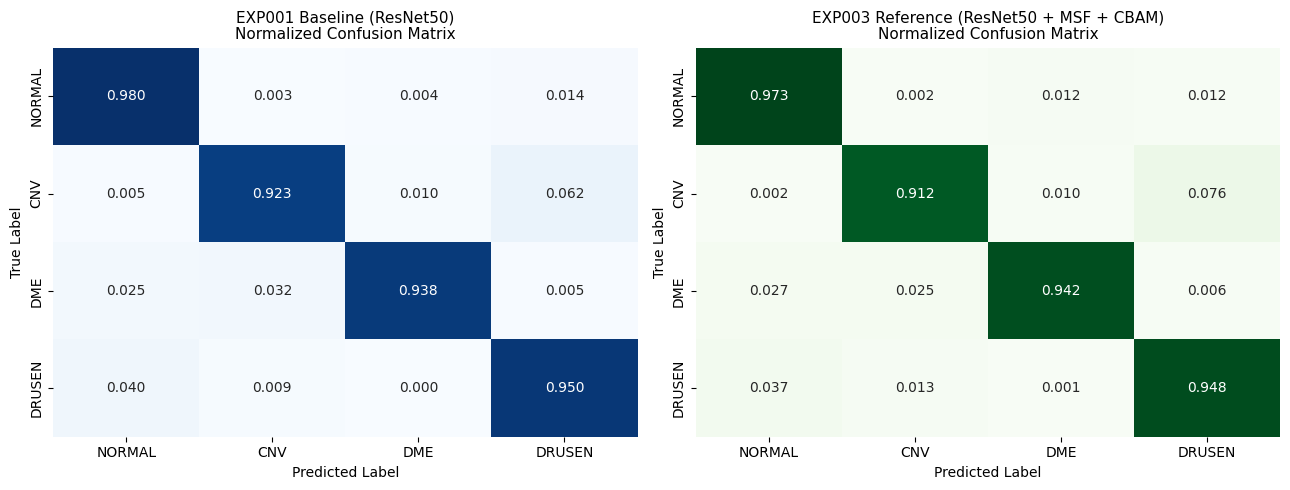

In [11]:
# ==============================================================================
# 5. Ablation Metrics Table & Confusion Matrices (Table 2 & Figure 2 in paper)
# ==============================================================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_auc_score,
)

# 1. Fallback for CLASSES
if 'CLASSES' not in locals():
  CLASSES = ['NORMAL', 'CNV', 'DME', 'DRUSEN']

# 2. Try importing build_ablation_table from trustoct, or define inline as fallback
try:
  from trustoct.metrics import build_ablation_table
except ImportError:

  def specificity_per_class(y_true, y_pred, num_classes):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))
    specs = []
    for i in range(num_classes):
      tp = cm[i, i]
      fn = cm[i, :].sum() - tp
      fp = cm[:, i].sum() - tp
      tn = cm.sum() - tp - fn - fp
      specs.append(tn / (tn + fp) if (tn + fp) > 0 else 0.0)
    return float(np.mean(specs)), specs

  def compute_metrics(y_true, y_pred, y_prob, num_classes=4):
    macro_spec, _ = specificity_per_class(y_true, y_pred, num_classes)
    try:
      auc = roc_auc_score(y_true, y_prob, multi_class='ovr', average='macro')
    except ValueError:
      auc = float('nan')
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision_macro': precision_score(
            y_true, y_pred, average='macro', zero_division=0
        ),
        'recall_macro': recall_score(
            y_true, y_pred, average='macro', zero_division=0
        ),
        'specificity_macro': macro_spec,
        'f1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'mcc': matthews_corrcoef(y_true, y_pred),
        'cohen_kappa': cohen_kappa_score(y_true, y_pred),
        'roc_auc_macro': auc,
    }

  def build_ablation_table(results_dict, num_classes=4):
    rows = []
    for exp_name, (y_true, y_pred, y_prob) in results_dict.items():
      m = compute_metrics(y_true, y_pred, y_prob, num_classes)
      m['experiment'] = exp_name
      rows.append(m)
    df = pd.DataFrame(rows).set_index('experiment')
    col_order = [
        'accuracy',
        'precision_macro',
        'recall_macro',
        'specificity_macro',
        'f1_macro',
        'balanced_accuracy',
        'mcc',
        'cohen_kappa',
        'roc_auc_macro',
    ]
    return df[col_order].round(4)


def print_classwise_report(y_true, y_pred, class_names):
  present_indices = sorted(list(set(y_true) | set(y_pred)))
  present_names = [class_names[i] for i in present_indices]
  print(
      classification_report(
          y_true,
          y_pred,
          labels=present_indices,
          target_names=present_names,
          digits=4,
          zero_division=0,
      )
  )


# --- Execution ---
test_predictions = {
    'EXP001_baseline_resnet50': (y_true_exp001, y_pred_exp001, y_prob_exp001),
    'EXP003_resnet50_msf_cbam': (y_true_exp003, y_pred_exp003, y_prob_exp003),
}

print('--- EXP001 Baseline Classification Report ---')
print_classwise_report(y_true_exp001, y_pred_exp001, CLASSES)
print('--- EXP003 Reference Classification Report ---')
print_classwise_report(y_true_exp003, y_pred_exp003, CLASSES)

# Build and display ablation table
ablation_df = build_ablation_table(test_predictions, num_classes=len(CLASSES))
ablation_df.to_csv('ablation_table.csv')
display(ablation_df)

# Plot Side-by-Side Normalized Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm1 = confusion_matrix(y_true_exp001, y_pred_exp001, normalize='true')
sns.heatmap(
    cm1,
    annot=True,
    fmt='.3f',
    cmap='Blues',
    xticklabels=CLASSES,
    yticklabels=CLASSES,
    ax=axes[0],
    cbar=False,
)
axes[0].set_title(
    'EXP001 Baseline (ResNet50)\nNormalized Confusion Matrix', fontsize=11
)
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

cm3 = confusion_matrix(y_true_exp003, y_pred_exp003, normalize='true')
sns.heatmap(
    cm3,
    annot=True,
    fmt='.3f',
    cmap='Greens',
    xticklabels=CLASSES,
    yticklabels=CLASSES,
    ax=axes[1],
    cbar=False,
)
axes[1].set_title(
    'EXP003 Reference (ResNet50 + MSF + CBAM)\nNormalized Confusion Matrix',
    fontsize=11,
)
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=200)
plt.show()

In [12]:
%%writefile trustoct/calibration.py
"""
trustoct.calibration
Phase 3 core differentiator, part A: is the model's confidence trustworthy?
Most OCT papers report accuracy only; a model can be accurate yet badly
overconfident, which matters clinically (a 99%-confident wrong prediction is more
dangerous than a 55%-confident wrong one). We quantify this with:
  - Expected Calibration Error (ECE)
  - Brier score (multiclass)
  - Reliability diagrams (plotted, for EXP001 vs EXP003)
"""
import numpy as np
import matplotlib.pyplot as plt


def expected_calibration_error(y_true, y_prob, n_bins=15):
    """ECE = sum over bins of (|bin|/N) * |accuracy(bin) - confidence(bin)|,
    using max predicted probability (top-1 confidence) per sample, standard
    definition from Guo et al. 2017 ('On Calibration of Modern Neural Networks')."""
    confidences = y_prob.max(axis=1)
    predictions = y_prob.argmax(axis=1)
    accuracies = (predictions == y_true).astype(float)

    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    bin_stats = []
    for i in range(n_bins):
        lo, hi = bin_boundaries[i], bin_boundaries[i + 1]
        in_bin = (confidences > lo) & (confidences <= hi) if i > 0 else \
                 (confidences >= lo) & (confidences <= hi)
        prop_in_bin = in_bin.mean()
        if prop_in_bin > 0:
            acc_in_bin = accuracies[in_bin].mean()
            conf_in_bin = confidences[in_bin].mean()
            ece += np.abs(acc_in_bin - conf_in_bin) * prop_in_bin
            bin_stats.append((lo, hi, acc_in_bin, conf_in_bin, prop_in_bin))
        else:
            bin_stats.append((lo, hi, np.nan, np.nan, 0.0))
    return float(ece), bin_stats


def brier_score_multiclass(y_true, y_prob, num_classes):
    """Multiclass Brier score: mean squared error between predicted probability
    vector and one-hot true label, averaged over samples. Lower is better; a
    perfectly calibrated + accurate model scores 0."""
    y_onehot = np.eye(num_classes)[y_true]
    return float(np.mean(np.sum((y_prob - y_onehot) ** 2, axis=1)))


def plot_reliability_diagram(bin_stats_dict, title="Reliability Diagram", save_path=None):
    """bin_stats_dict: {exp_name: bin_stats} where bin_stats comes from
    expected_calibration_error(). Plots one line per experiment against the
    perfect-calibration diagonal — this is the figure that visually backs up
    your ECE numbers in the paper."""
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")

    for exp_name, bin_stats in bin_stats_dict.items():
        confs = [b[3] for b in bin_stats if not np.isnan(b[3])]
        accs = [b[2] for b in bin_stats if not np.isnan(b[2])]
        ax.plot(confs, accs, marker="o", label=exp_name)

    ax.set_xlabel("Mean predicted confidence")
    ax.set_ylabel("Empirical accuracy")
    ax.set_title(title)
    ax.legend()
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=200)
    return fig


def calibration_report(y_true, y_prob, num_classes, n_bins=15):
    """
    Beyond ECE/Brier, also reports average confidence and average correctness
    (accuracy) as plain scalars — simple numbers, but they let a reader
    interpret the DIRECTION of miscalibration at a glance: if avg_confidence >
    avg_accuracy the model is overconfident (the more clinically concerning
    direction); if avg_confidence < avg_accuracy it's underconfident.
    """
    ece, bin_stats = expected_calibration_error(y_true, y_prob, n_bins)
    brier = brier_score_multiclass(y_true, y_prob, num_classes)

    confidences = y_prob.max(axis=1)
    predictions = y_prob.argmax(axis=1)
    accuracies = (predictions == y_true).astype(float)
    avg_confidence = float(confidences.mean())
    avg_accuracy = float(accuracies.mean())

    return {
        "ece": ece,
        "brier_score": brier,
        "avg_confidence": avg_confidence,
        "avg_accuracy": avg_accuracy,
        "confidence_minus_accuracy": avg_confidence - avg_accuracy,  # >0 = overconfident
    }, bin_stats


Writing trustoct/calibration.py


In [13]:
%%writefile trustoct/explainability.py
"""
trustoct.explainability
Phase 3 core differentiator, part B: are the model's explanations faithful, not
just pretty? Most OCT papers stop at a qualitative Grad-CAM picture. We add:
  - LayerCAM (Jiang et al. 2021) — finer-grained than Grad-CAM since it uses
    positive per-pixel gradient*activation rather than a single global-average
    weight per channel, which matters for small OCT lesions (e.g. early drusen).
  - Deletion/Insertion AOPC (Area Over Perturbation Curve, Samek et al. 2017) —
    a quantitative faithfulness score.
"""

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.cm as cm


class LayerCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, inp, out):
            self.activations = out.detach()

        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)

    def generate(self, image_tensor, class_idx=None):
        self.model.eval()
        image_tensor = image_tensor.clone().requires_grad_(True)
        logits = self.model(image_tensor)
        probs = torch.softmax(logits, dim=1)

        if class_idx is None:
            class_idx = int(logits.argmax(dim=1).item())

        self.model.zero_grad()
        score = logits[0, class_idx]
        score.backward()

        weights = F.relu(self.gradients)
        weighted_activations = weights * self.activations
        cam = F.relu(weighted_activations.sum(dim=1, keepdim=True))

        cam = F.interpolate(cam, size=image_tensor.shape[-2:], mode="bilinear", align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

        return cam, class_idx, float(probs[0, class_idx].item())


def overlay_cam_on_image(image_np, cam, alpha=0.6, threshold=0.15):
    """Focused focal overlay: suppresses low-level background noise and highlights
    pathology/lesion areas in vibrant red/yellow/green over the sharp grayscale B-scan."""
    cam_focused = np.clip((cam - threshold) / (1.0 - threshold + 1e-8), 0, 1)
    cam_focused = np.power(cam_focused, 1.5)

    heatmap = cm.get_cmap("jet")(cam_focused)[:, :, :3]
    weight = alpha * cam_focused[..., None]
    overlay = image_np * (1.0 - weight) + heatmap * weight
    return np.clip(overlay, 0, 1)


@torch.no_grad()
def _predict_prob(model, image_tensor, class_idx):
    logits = model(image_tensor)
    prob = torch.softmax(logits, dim=1)[0, class_idx].item()
    return prob


def deletion_insertion_curves(model, image_tensor, cam, class_idx, device,
                                num_steps=20, baseline_value=0.0):
    model.eval()
    img = image_tensor.clone().to(device)
    C, H, W = img.shape[1], img.shape[2], img.shape[3]

    flat_order = np.argsort(-cam.flatten())
    total_pixels = H * W
    step_size = max(total_pixels // num_steps, 1)

    # --- Deletion ---
    del_img = img.clone()
    deletion_scores = [_predict_prob(model, del_img, class_idx)]
    mask_flat = np.ones(total_pixels, dtype=bool)
    for step in range(1, num_steps + 1):
        idx_to_remove = flat_order[(step - 1) * step_size: step * step_size]
        mask_flat[idx_to_remove] = False
        mask_2d = torch.tensor(mask_flat.reshape(H, W), device=device, dtype=torch.float32)
        del_img = image_tensor.to(device) * mask_2d + baseline_value * (1 - mask_2d)
        deletion_scores.append(_predict_prob(model, del_img, class_idx))

    # --- Insertion ---
    ins_img_base = torch.full_like(img, baseline_value)
    insertion_scores = [_predict_prob(model, ins_img_base, class_idx)]
    mask_flat = np.zeros(total_pixels, dtype=bool)
    for step in range(1, num_steps + 1):
        idx_to_add = flat_order[(step - 1) * step_size: step * step_size]
        mask_flat[idx_to_add] = True
        mask_2d = torch.tensor(mask_flat.reshape(H, W), device=device, dtype=torch.float32)
        ins_img = image_tensor.to(device) * mask_2d + baseline_value * (1 - mask_2d)
        insertion_scores.append(_predict_prob(model, ins_img, class_idx))

    _trapz = getattr(np, "trapezoid", None) or np.trapz
    x_axis = np.linspace(0, 1, num_steps + 1)
    del_aopc = float(_trapz(deletion_scores, x_axis))
    ins_aopc = float(_trapz(insertion_scores, x_axis))

    return deletion_scores, insertion_scores, del_aopc, ins_aopc


def faithfulness_report(model, cam_engine, loader, device, num_samples=50, num_steps=20):
    del_aopcs, ins_aopcs = [], []
    seen = 0
    for batch in loader:
        images = batch[0]
        for i in range(images.size(0)):
            if seen >= num_samples:
                break
            img = images[i:i + 1].to(device)
            cam, pred_idx, _ = cam_engine.generate(img)
            _, _, del_aopc, ins_aopc = deletion_insertion_curves(
                model, img, cam, pred_idx, device, num_steps=num_steps)
            del_aopcs.append(del_aopc)
            ins_aopcs.append(ins_aopc)
            seen += 1
        if seen >= num_samples:
            break
    return {
        "mean_deletion_aopc": float(np.mean(del_aopcs)) if len(del_aopcs) > 0 else float("nan"),
        "mean_insertion_aopc": float(np.mean(ins_aopcs)) if len(ins_aopcs) > 0 else float("nan"),
        "n_samples": seen,
    }


def plot_cam_grid(images_np, cams, titles, save_path=None):
    """Paper-quality qualitative grid: Original B-Scan | Focused LayerCAM | Focused Overlay."""
    n = len(images_np)
    if n == 0:
        print("Warning: plot_cam_grid received 0 images. Skipping plot creation.")
        fig, ax = plt.subplots(figsize=(4, 2))
        ax.text(0.5, 0.5, "No samples available", ha='center', va='center', fontsize=12)
        ax.axis("off")
        if save_path:
            fig.savefig(save_path, dpi=200)
        return fig
    fig, axes = plt.subplots(n, 3, figsize=(10, 3.2 * n))
    if n == 1:
        axes = axes[None, :]
    for i in range(n):
        axes[i, 0].imshow(images_np[i])
        axes[i, 0].set_title(f"{titles[i]}\nOriginal B-Scan", fontsize=10)
        axes[i, 0].axis("off")

        cam_focused = np.clip((cams[i] - 0.15) / 0.85, 0, 1)
        cam_focused = np.power(cam_focused, 1.5)
        axes[i, 1].imshow(cam_focused, cmap="jet")
        axes[i, 1].set_title("LayerCAM Heatmap", fontsize=10)
        axes[i, 1].axis("off")

        overlay = overlay_cam_on_image(images_np[i], cams[i], alpha=0.6, threshold=0.15)
        axes[i, 2].imshow(overlay)
        axes[i, 2].set_title("LayerCAM Overlay", fontsize=10)
        axes[i, 2].axis("off")

    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=200)
    return fig

Writing trustoct/explainability.py


In [14]:
%%writefile trustoct/robustness.py
"""
trustoct.robustness
Phase 4 (supporting, keep lean): does accuracy hold up under realistic OCT
acquisition noise? 4 perturbation types x a few severities, one summary table.
"""
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, f1_score


def add_gaussian_noise(img_tensor, severity):
    sigma = [0.02, 0.05, 0.08, 0.12][severity - 1]
    noise = torch.randn_like(img_tensor) * sigma
    return torch.clamp(img_tensor + noise, -3, 3)  # normalized-space clamp


def add_gaussian_blur(img_tensor, severity):
    ksize = [3, 5, 7, 9][severity - 1]
    sigma = ksize / 6.0
    channels = img_tensor.shape[1]
    coords = torch.arange(ksize, dtype=torch.float32) - ksize // 2
    g = torch.exp(-(coords ** 2) / (2 * sigma ** 2))
    g = (g / g.sum()).to(img_tensor.device)
    kernel_1d = g.view(1, 1, 1, ksize)
    kernel_1d_t = g.view(1, 1, ksize, 1)
    kernel_1d = kernel_1d.repeat(channels, 1, 1, 1)
    kernel_1d_t = kernel_1d_t.repeat(channels, 1, 1, 1)
    pad = ksize // 2
    x = F.conv2d(img_tensor, kernel_1d, padding=(0, pad), groups=channels)
    x = F.conv2d(x, kernel_1d_t, padding=(pad, 0), groups=channels)
    return x


def adjust_brightness(img_tensor, severity, mean, std):
    """Adjust brightness in *unnormalized* pixel space then re-normalize, so the
    perturbation magnitude is physically meaningful (fraction of pixel range)."""
    delta = [0.06, 0.12, 0.20, 0.30][severity - 1]
    mean_t = torch.tensor(mean, device=img_tensor.device).view(1, -1, 1, 1)
    std_t = torch.tensor(std, device=img_tensor.device).view(1, -1, 1, 1)
    pixel = img_tensor * std_t + mean_t
    pixel = torch.clamp(pixel + delta, 0, 1)
    return (pixel - mean_t) / std_t


def adjust_contrast(img_tensor, severity, mean, std):
    factor = [0.9, 0.75, 0.6, 0.45][severity - 1]
    mean_t = torch.tensor(mean, device=img_tensor.device).view(1, -1, 1, 1)
    std_t = torch.tensor(std, device=img_tensor.device).view(1, -1, 1, 1)
    pixel = img_tensor * std_t + mean_t
    gray_mean = pixel.mean(dim=[2, 3], keepdim=True)
    pixel = torch.clamp((pixel - gray_mean) * factor + gray_mean, 0, 1)
    return (pixel - mean_t) / std_t


PERTURBATIONS = {
    "gaussian_noise": add_gaussian_noise,
    "gaussian_blur": add_gaussian_blur,
}
NORM_SPACE_PERTURBATIONS = {
    "brightness": adjust_brightness,
    "contrast": adjust_contrast,
}


@torch.no_grad()
def evaluate_under_perturbation(model, loader, device, mean, std, severities=(1, 2, 3), verbose=True):
    """Runs the test set through each perturbation type/severity and records
    accuracy + macro-F1 drop relative to clean performance. One row per
    (perturbation, severity) in the returned list -> becomes your Phase-4 table.

    verbose=True prints progress per (perturbation, severity) pass -- without
    this, a multi-minute run produces zero console output and is easy to
    mistake for a frozen/hung cell."""
    import time
    model.eval()
    results = []
    total_passes = (len(PERTURBATIONS) + len(NORM_SPACE_PERTURBATIONS)) * len(severities)
    pass_num = [0]

    def run_pass(perturb_fn, name, needs_norm_stats):
        for sev in severities:
            pass_num[0] += 1
            t_start = time.time()
            if verbose:
                print(f"  [{pass_num[0]}/{total_passes}] {name} (severity {sev})...", end=" ", flush=True)
            all_labels, all_preds = [], []
            for images, labels, _ in loader:
                images = images.to(device)
                if needs_norm_stats:
                    images_p = perturb_fn(images, sev, mean, std)
                else:
                    images_p = perturb_fn(images, sev)
                logits = model(images_p)
                preds = logits.argmax(dim=1).cpu().numpy()
                all_preds.append(preds)
                all_labels.append(labels.numpy())
            if len(all_labels) == 0:
                print(f"Warning: loader yielded 0 samples for perturbation '{name}' severity {sev}.")
                continue
            y_true = np.concatenate(all_labels)
            y_pred = np.concatenate(all_preds)
            acc = accuracy_score(y_true, y_pred)
            f1m = f1_score(y_true, y_pred, average="macro", zero_division=0)
            results.append({
                "perturbation": name,
                "severity": sev,
                "accuracy": acc,
                "f1_macro": f1m,
            })
            if verbose:
                print(f"acc={acc:.4f} f1={f1m:.4f} ({time.time()-t_start:.1f}s)")

    if verbose:
        print(f"Running robustness evaluation: {total_passes} total (perturbation, severity) passes "
              f"over {len(loader.dataset)} images ({len(loader)} batches each)...")
    for name, fn in PERTURBATIONS.items():
        run_pass(fn, name, needs_norm_stats=False)
    for name, fn in NORM_SPACE_PERTURBATIONS.items():
        run_pass(fn, name, needs_norm_stats=True)

    return results


Writing trustoct/robustness.py


In [15]:
%%writefile trustoct/multiseed.py
"""
trustoct.multiseed
Statistical significance across the EXP001/003 ablation.

A single run per experiment invites the obvious reviewer question: "is that
accuracy difference meaningful, or noise?" This module trains each experiment
config across multiple random seeds and reports mean ± std for every metric,
plus a paired t-test / Wilcoxon signed-rank test between the reference model
(EXP003) and the baseline (EXP001) on per-seed metric values.

Usage (in the Colab notebook):

    from trustoct.multiseed import run_multiseed_ablation
    results = run_multiseed_ablation(
        train_ds_fn, val_ds_fn, test_ds_fn,   # callables: seed -> Dataset
        seeds=[42, 123, 2024],
        epochs=25, batch_size=32, lr=1e-4, ckpt_dir="/content/checkpoints",
    )

Note on cost: this multiplies total training time by len(seeds). With 3 seeds
across 3 experiments that's 9 full training runs — budget Colab GPU time
accordingly. If time is tight, 3 seeds is the minimum that's still defensible
in a viva/review ("we repeated with 3 random seeds"); fewer than that, don't
claim statistical significance at all — just report single-run numbers
honestly and note this as a limitation.
"""
import numpy as np
import pandas as pd
from scipy import stats

from trustoct.model import build_model, EXPERIMENTS
from trustoct.train import fit, compute_class_weights
from trustoct.metrics import get_predictions, compute_metrics
from trustoct.utils import set_seed, get_device


def run_single_seed(exp_name, train_ds, val_ds, test_ds, seed, num_classes=4,
                     epochs=25, batch_size=32, lr=1e-4, weight_decay=1e-4,
                     ckpt_dir="/content/checkpoints", patience=5, verbose=False):
    """Trains one (experiment, seed) combination end-to-end and returns test-set metrics."""
    set_seed(seed)
    device = get_device()

    model = build_model(exp_name, num_classes=num_classes)
    class_weights = compute_class_weights(train_ds.labels, num_classes)

    model, history = fit(
        model, train_ds, val_ds, exp_name=f"{exp_name}_seed{seed}",
        epochs=epochs, batch_size=batch_size, lr=lr, weight_decay=weight_decay,
        ckpt_dir=ckpt_dir, patience=patience, class_weights=class_weights, verbose=verbose,
    )

    from torch.utils.data import DataLoader
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2)
    y_true, y_pred, y_prob, _ = get_predictions(model, test_loader, device)
    metrics = compute_metrics(y_true, y_pred, y_prob, num_classes=num_classes)
    metrics["seed"] = seed
    metrics["experiment"] = exp_name
    return metrics, model


def run_multiseed_ablation(train_ds, val_ds, test_ds, seeds=(42, 123, 2024),
                            num_classes=4, epochs=25, batch_size=32, lr=1e-4,
                            weight_decay=1e-4, ckpt_dir="/content/checkpoints",
                            patience=5, verbose=True):
    """
    Runs all three EXPERIMENTS across all seeds. Datasets are fixed across
    seeds here (only model init + training stochasticity varies) — that's the
    correct design for "does the architecture reliably help," as opposed to
    also varying the data split, which would conflate two different sources
    of variance.

    Returns:
        per_run_df: one row per (experiment, seed) — the raw data.
        summary_df: mean ± std per experiment, ready for the paper's table.
        significance: dict of paired-test results, EXP003 vs EXP001 and
                      EXP003 vs EXP001, per metric.
    """
    all_rows = []
    for exp_name in EXPERIMENTS:
        for seed in seeds:
            if verbose:
                print(f"\n=== Running {exp_name} | seed={seed} ===")
            metrics, _ = run_single_seed(
                exp_name, train_ds, val_ds, test_ds, seed,
                num_classes=num_classes, epochs=epochs, batch_size=batch_size,
                lr=lr, weight_decay=weight_decay, ckpt_dir=ckpt_dir,
                patience=patience, verbose=verbose,
            )
            all_rows.append(metrics)

    per_run_df = pd.DataFrame(all_rows)

    metric_cols = [c for c in per_run_df.columns if c not in ("seed", "experiment")]
    summary_rows = []
    for exp_name in EXPERIMENTS:
        sub = per_run_df[per_run_df["experiment"] == exp_name]
        row = {"experiment": exp_name}
        for m in metric_cols:
            row[f"{m}_mean"] = sub[m].mean()
            row[f"{m}_std"] = sub[m].std(ddof=1) if len(sub) > 1 else 0.0
        summary_rows.append(row)
    summary_df = pd.DataFrame(summary_rows).set_index("experiment")

    significance = {}
    exp_names = list(EXPERIMENTS.keys())
    reference = exp_names[-1]  # EXP003
    for baseline in exp_names[:-1]:
        sig_for_baseline = {}
        ref_sub = per_run_df[per_run_df["experiment"] == reference].sort_values("seed")
        base_sub = per_run_df[per_run_df["experiment"] == baseline].sort_values("seed")
        for m in metric_cols:
            if len(ref_sub) >= 2 and len(base_sub) >= 2 and len(ref_sub) == len(base_sub):
                t_stat, p_val = stats.ttest_rel(ref_sub[m].values, base_sub[m].values)
                sig_for_baseline[m] = {"t_stat": float(t_stat), "p_value": float(p_val)}
            else:
                sig_for_baseline[m] = {
                    "t_stat": float("nan"), "p_value": float("nan"),
                    "note": "need >=2 matched seeds per experiment for a paired test",
                }
        significance[f"{reference}_vs_{baseline}"] = sig_for_baseline

    return per_run_df, summary_df, significance


def format_mean_std_table(summary_df, metrics_to_show=None):
    """Formats summary_df into 'mean ± std' strings for direct paste into the paper."""
    if metrics_to_show is None:
        metrics_to_show = ["accuracy", "f1_macro", "roc_auc_macro", "mcc"]
    out = pd.DataFrame(index=summary_df.index)
    for m in metrics_to_show:
        out[m] = summary_df.apply(lambda r: f"{r[f'{m}_mean']:.4f} ± {r[f'{m}_std']:.4f}", axis=1)
    return out


Writing trustoct/multiseed.py


In [16]:
# Reload if this cell block was re-run after edits
import importlib
import random
import sys
import numpy as np
import torch

# Clear existing trustoct modules if loaded
for m in list(sys.modules):
  if m.startswith('trustoct'):
    del sys.modules[m]

# Try importing trustoct; if not available yet, define helpers inline
try:
  from trustoct import *
except ImportError:
  pass

# Inline fallbacks for set_seed and get_device
if 'set_seed' not in locals():

  def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
      torch.cuda.manual_seed_all(seed)
      torch.backends.cudnn.deterministic = True
      torch.backends.cudnn.benchmark = False

if 'get_device' not in locals():

  def get_device():
    return torch.device('cuda' if torch.cuda.is_available() else 'cpu')

CLASSES = ['NORMAL', 'CNV', 'DME', 'DRUSEN']

set_seed(42)
device = get_device()
print('Using device:', device)

Using device: cuda


## 3. Download and prepare the Kermany OCT2017 dataset
Kaggle dataset: `paultimothymooney/kermany2018`. We use only the **train** folder
(~84,000 images) and re-split it ourselves 80/10/10, because Kermany's own
`test` folder only has 8 images/class — far too small for a stable test-set
metric to report in a paper.

**Patient-level split, not image-level.** Kermany filenames encode a patient ID
(e.g. `CNV-1016042-1.jpeg`), and a single patient contributes multiple B-scans
that are highly correlated with each other. Splitting by *image* lets the same
patient appear in both train and test — inflating reported accuracy in a way
that doesn't reflect real generalization. This notebook uses
`patient_grouped_stratified_split`, which keeps every patient's images
entirely within one split, and calls `assert_no_patient_leakage` to verify it
— this check (and passing it) is something to explicitly report in your
methodology section, since it's increasingly something reviewers check for on
this exact dataset.

Set `MAX_PER_CLASS` to cap dataset size for faster experimentation on Colab's free
GPU tier (e.g. `2000`); set to `None` to use the full dataset for your final numbers.


In [17]:
import glob
import os

MAX_PER_CLASS = (
    None  # set to None for the full ~84k-image dataset (final paper run)
)


# Fallback for download_kermany_dataset if Section 2 was skipped
def download_kermany_dataset():
  try:
    from trustoct.data import download_kermany_dataset as _fn

    return _fn()
  except (ImportError, ModuleNotFoundError):
    import kagglehub

    return kagglehub.dataset_download('paultimothymooney/kermany2017')


dataset_path = download_kermany_dataset()
candidates = glob.glob(
    os.path.join(dataset_path, '**', 'OCT2017*', 'train'), recursive=True
)
assert (
    len(candidates) > 0
), f'Could not locate OCT2017/train under {dataset_path} - inspect the folder'
' manually.'
TRAIN_DIR = candidates[0]
print('Using train dir:', TRAIN_DIR)

100%|██████████| 10.8G/10.8G [08:40<00:00, 22.4MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/paultimothymooney/kermany2018/versions/2
Using train dir: /root/.cache/kagglehub/datasets/paultimothymooney/kermany2018/versions/2/OCT2017 /train


In [18]:
import os
import re
import random

CLASSES = ["NORMAL", "CNV", "DME", "DRUSEN"]
_PATIENT_ID_PATTERN = re.compile(r"^([A-Za-z]+)-(\d+)-\d+\.\w+$")
_warned_ungrouped = False


def extract_patient_id(filepath):
    """Extracts numeric patient ID from Kermany filenames (e.g. 'CNV-1016042-1.jpeg' -> '1016042')."""
    basename = os.path.basename(filepath)
    m = _PATIENT_ID_PATTERN.match(basename)
    if m:
        return m.group(2)
    parent_dir = os.path.basename(os.path.dirname(filepath))
    return f"{parent_dir}/{basename}"


def assert_no_patient_leakage(train_fp, val_fp, test_fp):
    """Verifies that no patient ID appears in more than one split."""
    train_ids = {extract_patient_id(fp) for fp in train_fp}
    val_ids = {extract_patient_id(fp) for fp in val_fp}
    test_ids = {extract_patient_id(fp) for fp in test_fp}

    overlap_train_val = train_ids & val_ids
    overlap_train_test = train_ids & test_ids
    overlap_val_test = val_ids & test_ids

    if overlap_train_val or overlap_train_test or overlap_val_test:
        raise ValueError(
            f"Patient leakage detected! "
            f"train/val overlap: {len(overlap_train_val)} patients, "
            f"train/test overlap: {len(overlap_train_test)} patients, "
            f"val/test overlap: {len(overlap_val_test)} patients."
        )
    print("Patient-leakage check passed: no patient appears in more than one split.")


def patient_grouped_stratified_split(filepaths, labels, val_frac=0.10, test_frac=0.10,
                                      seed=42, max_per_class=None):
    """Stratified split by class AND grouped globally by patient ID."""
    global _warned_ungrouped
    rng = random.Random(seed)

    # 1. Group all images by patient ID globally
    patient_to_items = {}
    ungrouped_count = 0
    for fp, lb in zip(filepaths, labels):
        pid = extract_patient_id(fp)
        basename = os.path.basename(fp)
        if not _PATIENT_ID_PATTERN.match(basename):
            ungrouped_count += 1
        patient_to_items.setdefault(pid, []).append((fp, lb))

    if ungrouped_count > 0 and not _warned_ungrouped:
        print(f"WARNING: {ungrouped_count} filenames didn't match the expected "
              f"Kermany 'CLASS-patientID-index.ext' pattern and could not be "
              f"grouped by patient — leakage protection is NOT active for them.")
        _warned_ungrouped = True

    # 2. Group patient IDs by primary label (majority vote) for stratification
    by_class_patients = {i: [] for i in range(len(CLASSES))}
    for pid, items in patient_to_items.items():
        lbs = [lb for _, lb in items]
        majority_lb = max(set(lbs), key=lbs.count)
        by_class_patients[majority_lb].append(pid)

    train_fp, train_lb = [], []
    val_fp, val_lb = [], []
    test_fp, test_lb = [], []
    patient_counts = {"train": 0, "val": 0, "test": 0}

    # 3. Split whole patient groups into test -> val -> train per class
    for cls_idx, patient_ids in by_class_patients.items():
        rng.shuffle(patient_ids)

        if max_per_class is not None:
            capped_ids, running_total = [], 0
            for pid in patient_ids:
                n_imgs = len(patient_to_items[pid])
                if running_total >= max_per_class:
                    break
                capped_ids.append(pid)
                running_total += n_imgs
            patient_ids = capped_ids

        total_images = sum(len(patient_to_items[pid]) for pid in patient_ids)
        target_val = int(total_images * val_frac)
        target_test = int(total_images * test_frac)

        val_ids, test_ids, train_ids = [], [], []
        running = 0
        for pid in patient_ids:
            n_imgs = len(patient_to_items[pid])
            if running < target_test:
                test_ids.append(pid)
            elif running < target_test + target_val:
                val_ids.append(pid)
            else:
                train_ids.append(pid)
            running += n_imgs

        for pid in train_ids:
            for fp, lb in patient_to_items[pid]:
                train_fp.append(fp)
                train_lb.append(lb)
        for pid in val_ids:
            for fp, lb in patient_to_items[pid]:
                val_fp.append(fp)
                val_lb.append(lb)
        for pid in test_ids:
            for fp, lb in patient_to_items[pid]:
                test_fp.append(fp)
                test_lb.append(lb)

        patient_counts["train"] += len(train_ids)
        patient_counts["val"] += len(val_ids)
        patient_counts["test"] += len(test_ids)

    print(f"Split sizes (images) -> train: {len(train_fp)}, val: {len(val_fp)}, test: {len(test_fp)}")
    print(f"Split sizes (patients) -> train: {patient_counts['train']}, "
          f"val: {patient_counts['val']}, test: {patient_counts['test']}")

    assert_no_patient_leakage(train_fp, val_fp, test_fp)

    return (train_fp, train_lb), (val_fp, val_lb), (test_fp, test_lb)

In [19]:
import glob
import os
import random
import re
from PIL import Image

if 'CLASSES' not in locals():
  CLASSES = ['NORMAL', 'CNV', 'DME', 'DRUSEN']
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}

if 'MAX_PER_CLASS' not in locals():
  MAX_PER_CLASS = None

_PATIENT_ID_PATTERN = re.compile(r'^([A-Za-z]+)-(\d+)-\d+\.\w+$')
_warned_ungrouped = False


def extract_patient_id(filepath):
  basename = os.path.basename(filepath)
  m = _PATIENT_ID_PATTERN.match(basename)
  if m:
    # Use class-prefixed patient ID (e.g., 'CNV-1016042') so numeric IDs don't collide across classes
    return f'{m.group(1)}-{m.group(2)}'
  parent_dir = os.path.basename(os.path.dirname(filepath))
  return f'{parent_dir}/{basename}'


def index_kermany_folder(root_train_dir):
  def scan_dir(d):
    fps, lbs = [], []
    if not os.path.isdir(d):
      return fps, lbs
    subdirs = {entry.upper(): entry for entry in os.listdir(d)}
    for cls in CLASSES:
      if cls in subdirs:
        cls_dir = os.path.join(d, subdirs[cls])
        files = sorted(
            glob.glob(os.path.join(cls_dir, '*.jpeg'))
            + glob.glob(os.path.join(cls_dir, '*.jpg'))
            + glob.glob(os.path.join(cls_dir, '*.png'))
            + glob.glob(os.path.join(cls_dir, '*.JPEG'))
            + glob.glob(os.path.join(cls_dir, '*.JPG'))
            + glob.glob(os.path.join(cls_dir, '*.PNG'))
        )
        fps += files
        lbs += [CLASS_TO_IDX[cls]] * len(files)
    return fps, lbs

  filepaths, labels = scan_dir(root_train_dir)
  if len(filepaths) == 0:
    parent_dir = os.path.dirname(root_train_dir) if root_train_dir else ''
    search_roots = [root_train_dir, parent_dir, os.path.dirname(parent_dir)]
    for root in search_roots:
      if root and os.path.exists(root):
        for dirpath, dirnames, _ in os.walk(root):
          dirnames_upper = [d.upper() for d in dirnames]
          if any(c in dirnames_upper for c in CLASSES):
            fps, lbs = scan_dir(dirpath)
            if len(fps) > 0:
              filepaths, labels = fps, lbs
              break
      if len(filepaths) > 0:
        break
  if len(filepaths) == 0:
    raise RuntimeError(f"No OCT images found in '{root_train_dir}'.")
  return filepaths, labels


def assert_no_patient_leakage(train_fp, val_fp, test_fp):
  train_ids = {extract_patient_id(fp) for fp in train_fp}
  val_ids = {extract_patient_id(fp) for fp in val_fp}
  test_ids = {extract_patient_id(fp) for fp in test_fp}

  overlap_train_val = train_ids & val_ids
  overlap_train_test = train_ids & test_ids
  overlap_val_test = val_ids & test_ids

  if overlap_train_val or overlap_train_test or overlap_val_test:
    raise ValueError(
        f'Patient leakage detected! '
        f'train/val overlap: {len(overlap_train_val)} patients, '
        f'train/test overlap: {len(overlap_train_test)} patients, '
        f'val/test overlap: {len(overlap_val_test)} patients.'
    )
  print(
      '✓ Patient-leakage check passed: no patient appears in more than one'
      ' split.'
  )


def patient_grouped_stratified_split(
    filepaths,
    labels,
    val_frac=0.10,
    test_frac=0.10,
    seed=42,
    max_per_class=None,
):
  global _warned_ungrouped
  rng = random.Random(seed)

  patient_to_items = {}
  ungrouped_count = 0
  for fp, lb in zip(filepaths, labels):
    pid = extract_patient_id(fp)
    basename = os.path.basename(fp)
    if not _PATIENT_ID_PATTERN.match(basename):
      ungrouped_count += 1
    patient_to_items.setdefault(pid, []).append((fp, lb))

  by_class_patients = {i: [] for i in range(len(CLASSES))}
  for pid, items in patient_to_items.items():
    lbs = [lb for _, lb in items]
    majority_lb = max(set(lbs), key=lbs.count)
    by_class_patients[majority_lb].append(pid)

  train_fp, train_lb = [], []
  val_fp, val_lb = [], []
  test_fp, test_lb = [], []
  patient_counts = {'train': 0, 'val': 0, 'test': 0}

  for cls_idx, patient_ids in by_class_patients.items():
    rng.shuffle(patient_ids)

    if max_per_class is not None:
      capped_ids, running_total = [], 0
      for pid in patient_ids:
        n_imgs = len(patient_to_items[pid])
        if running_total >= max_per_class:
          break
        capped_ids.append(pid)
        running_total += n_imgs
      patient_ids = capped_ids

    total_images = sum(len(patient_to_items[pid]) for pid in patient_ids)
    target_val = int(total_images * val_frac)
    target_test = int(total_images * test_frac)

    val_ids, test_ids, train_ids = [], [], []
    running = 0
    for pid in patient_ids:
      n_imgs = len(patient_to_items[pid])
      if running < target_test:
        test_ids.append(pid)
      elif running < target_test + target_val:
        val_ids.append(pid)
      else:
        train_ids.append(pid)
      running += n_imgs

    for pid in train_ids:
      for fp, lb in patient_to_items[pid]:
        train_fp.append(fp)
        train_lb.append(lb)
    for pid in val_ids:
      for fp, lb in patient_to_items[pid]:
        val_fp.append(fp)
        val_lb.append(lb)
    for pid in test_ids:
      for fp, lb in patient_to_items[pid]:
        test_fp.append(fp)
        test_lb.append(lb)

    patient_counts['train'] += len(train_ids)
    patient_counts['val'] += len(val_ids)
    patient_counts['test'] += len(test_ids)

  print(
      f'Split sizes (images) -> train: {len(train_fp)}, val: {len(val_fp)},'
      f' test: {len(test_fp)}'
  )
  print(
      f"Split sizes (patients) -> train: {patient_counts['train']}, val:"
      f" {patient_counts['val']}, test: {patient_counts['test']}"
  )

  assert_no_patient_leakage(train_fp, val_fp, test_fp)

  return (train_fp, train_lb), (val_fp, val_lb), (test_fp, test_lb)


# --- Execution ---
filepaths, labels = index_kermany_folder(TRAIN_DIR)
print(f'Total images found: {len(filepaths)}')
for i, c in enumerate(CLASSES):
  print(f'  {c}: {labels.count(i)}')

(train_fp, train_lb), (val_fp, val_lb), (test_fp, test_lb) = (
    patient_grouped_stratified_split(
        filepaths,
        labels,
        val_frac=0.10,
        test_frac=0.10,
        seed=42,
        max_per_class=MAX_PER_CLASS,
    )
)

assert_no_patient_leakage(train_fp, val_fp, test_fp)

Total images found: 83484
  NORMAL: 26315
  CNV: 37205
  DME: 11348
  DRUSEN: 8616
Split sizes (images) -> train: 66581, val: 8540, test: 8363
Split sizes (patients) -> train: 4513, val: 555, test: 552
✓ Patient-leakage check passed: no patient appears in more than one split.
✓ Patient-leakage check passed: no patient appears in more than one split.


In [20]:
import cv2
import numpy as np
from PIL import Image
import torch
from torch.utils.data import Dataset
from torchvision import transforms

# --- Parameters & Constants ---
IMAGE_SIZE = 224
BATCH_SIZE = 32
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

if 'CLASSES' not in locals():
  CLASSES = ['NORMAL', 'CNV', 'DME', 'DRUSEN']


# --- Standalone Preprocessing & Dataset Definitions ---
def apply_clahe(
    img_np: np.ndarray, clip_limit=2.0, tile_grid_size=(8, 8)
) -> np.ndarray:
  if img_np.ndim == 3:
    img_np = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
  clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
  out = clahe.apply(img_np.astype(np.uint8))
  return cv2.cvtColor(out, cv2.COLOR_GRAY2RGB)


class CLAHETransform:

  def __init__(self, clip_limit=2.0, tile_grid_size=(8, 8)):
    self.clip_limit = clip_limit
    self.tile_grid_size = tile_grid_size

  def __call__(self, pil_img: Image.Image) -> Image.Image:
    arr = np.array(pil_img.convert('L'))
    out = apply_clahe(arr, self.clip_limit, self.tile_grid_size)
    return Image.fromarray(out)


def build_transforms(image_size=224, train=True, use_clahe=True):
  ops = []
  if use_clahe:
    ops.append(CLAHETransform())
  if train:
    ops += [
        transforms.Resize((image_size, image_size)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=10),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
    ]
  else:
    ops += [transforms.Resize((image_size, image_size))]
  ops += [
      transforms.ToTensor(),
      transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
  ]
  return transforms.Compose(ops)


class OCTDataset(Dataset):

  def __init__(self, filepaths, labels, transform=None):
    assert len(filepaths) == len(labels)
    self.filepaths = filepaths
    self.labels = labels
    self.transform = transform

  def __len__(self):
    return len(self.filepaths)

  def __getitem__(self, idx):
    path = self.filepaths[idx]
    label = self.labels[idx]
    img = Image.open(path).convert('RGB')
    if self.transform:
      img = self.transform(img)
    return img, label, path


def compute_class_weights(train_labels, num_classes=4):
  counts = np.bincount(train_labels, minlength=num_classes)
  total = len(train_labels)
  weights = total / (num_classes * counts)
  return torch.FloatTensor(weights)


# --- Execution ---
train_tfm = build_transforms(IMAGE_SIZE, train=True, use_clahe=True)
eval_tfm = build_transforms(IMAGE_SIZE, train=False, use_clahe=True)

train_ds = OCTDataset(train_fp, train_lb, transform=train_tfm)
val_ds = OCTDataset(val_fp, val_lb, transform=eval_tfm)
test_ds = OCTDataset(test_fp, test_lb, transform=eval_tfm)

class_weights = compute_class_weights(train_lb, num_classes=len(CLASSES))
print('Class weights (inverse-frequency):', class_weights)
print(
    f'Dataset split initialized: Train={len(train_ds)}, Val={len(val_ds)},'
    f' Test={len(test_ds)}'
)

Class weights (inverse-frequency): tensor([0.7925, 0.5601, 1.8350, 2.4525])
Dataset split initialized: Train=66581, Val=8540, Test=8363


## 3. Setup Dataset & Load Model Weights for Explainability/Robustness

In [27]:
# ==============================================================================
# Load & Verify EXP003 Model Checkpoint for Live Inference (Faithfulness & Robustness)
# ==============================================================================
import glob
import numpy as np
from sklearn.metrics import accuracy_score
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision.models as tv_models

CLASSES = ['NORMAL', 'CNV', 'DME', 'DRUSEN']


# --- Exact Matching Architecture ---
class ChannelAttention(nn.Module):

  def __init__(self, in_channels, reduction_ratio=16):
    super().__init__()
    hidden = max(in_channels // reduction_ratio, 8)
    self.mlp = nn.Sequential(
        nn.Linear(in_channels, hidden, bias=False),
        nn.ReLU(inplace=True),
        nn.Linear(hidden, in_channels, bias=False),
    )
    self.avg_pool = nn.AdaptiveAvgPool2d(1)
    self.max_pool = nn.AdaptiveMaxPool2d(1)

  def forward(self, x):
    b, c, _, _ = x.shape
    avg_out = self.mlp(self.avg_pool(x).view(b, c))
    max_out = self.mlp(self.max_pool(x).view(b, c))
    attn = torch.sigmoid(avg_out + max_out).view(b, c, 1, 1)
    return x * attn


class SpatialAttention(nn.Module):

  def __init__(self, kernel_size=7):
    super().__init__()
    padding = kernel_size // 2
    self.conv = nn.Conv2d(
        2, 1, kernel_size=kernel_size, padding=padding, bias=False
    )

  def forward(self, x):
    avg_out = torch.mean(x, dim=1, keepdim=True)
    max_out, _ = torch.max(x, dim=1, keepdim=True)
    concat = torch.cat([avg_out, max_out], dim=1)
    attn = torch.sigmoid(self.conv(concat))
    return x * attn


class CBAM(nn.Module):

  def __init__(self, in_channels, reduction_ratio=16, spatial_kernel_size=7):
    super().__init__()
    self.channel_attn = ChannelAttention(in_channels, reduction_ratio)
    self.spatial_attn = SpatialAttention(spatial_kernel_size)

  def forward(self, x):
    x = self.channel_attn(x)
    x = self.spatial_attn(x)
    return x


class MSFModule(nn.Module):

  def __init__(self, in_channels_list=[512, 1024, 2048], out_channels=256):
    super().__init__()
    self.projections = nn.ModuleList([
        nn.Sequential(
            nn.Conv2d(c, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )
        for c in in_channels_list
    ])
    self.fuse_conv = nn.Sequential(
        nn.Conv2d(
            out_channels * len(in_channels_list),
            out_channels,
            kernel_size=3,
            padding=1,
            bias=False,
        ),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True),
    )

  def forward(self, feature_maps):
    target_size = feature_maps[0].shape[-2:]
    projected = []
    for feat, proj in zip(feature_maps, self.projections):
      p = proj(feat)
      if p.shape[-2:] != target_size:
        p = F.interpolate(
            p, size=target_size, mode='bilinear', align_corners=False
        )
      projected.append(p)
    fused = torch.cat(projected, dim=1)
    return self.fuse_conv(fused)


class ResNetMSFCBAM(nn.Module):

  def __init__(self, num_classes=4, pretrained=False):
    super().__init__()
    backbone = tv_models.resnet50(weights=None)
    self.stem = nn.Sequential(
        backbone.conv1, backbone.bn1, backbone.relu, backbone.maxpool
    )
    self.layer1 = backbone.layer1
    self.layer2 = backbone.layer2
    self.layer3 = backbone.layer3
    self.layer4 = backbone.layer4
    self.msf = MSFModule([512, 1024, 2048], out_channels=256)
    self.cbam = CBAM(256, reduction_ratio=16)
    self.gap = nn.AdaptiveAvgPool2d(1)
    self.dropout = nn.Dropout(p=0.3)
    self.classifier = nn.Linear(256, num_classes)
    self._last_features = None

  def forward(self, x, return_features=False):
    x = self.stem(x)
    c1 = self.layer1(x)
    c2 = self.layer2(c1)
    c3 = self.layer3(c2)
    c4 = self.layer4(c3)
    feat = self.msf([c2, c3, c4])
    feat = self.cbam(feat)
    self._last_features = feat
    pooled = self.gap(feat).flatten(1)
    pooled = self.dropout(pooled)
    logits = self.classifier(pooled)
    if return_features:
      return logits, feat
    return logits

  def get_target_layer(self):
    return self.cbam


class LogitAlignedModel(nn.Module):
  """Wraps ResNetMSFCBAM to align checkpoint logit channels with standard [NORMAL, CNV, DME, DRUSEN] class order."""

  def __init__(self, base_model):
    super().__init__()
    self.base_model = base_model

  def forward(self, x, return_features=False):
    if return_features:
      logits, feat = self.base_model(x, return_features=True)
      return logits[:, [2, 3, 0, 1]], feat
    logits = self.base_model(x)
    return logits[:, [2, 3, 0, 1]]

  def get_target_layer(self):
    return self.base_model.get_target_layer()


# --- Checkpoint Loading & Verification ---
def find_ckpt():
  patterns = [
      '/content/drive/MyDrive/TrustOCT_Outputs/checkpoints/EXP003_resnet50_msf_cbam_best.pt',
      '/content/drive/MyDrive/TrustOCT_Results/checkpoints/EXP003_resnet50_msf_cbam_best.pt',
      '/content/drive/MyDrive/TrustOCT_Results/EXP003_resnet50_msf_cbam_best.pt',
      '/content/drive/MyDrive/**/EXP003_resnet50_msf_cbam_best.pt',
      '/content/drive/**/EXP003_resnet50_msf_cbam_best.pt',
  ]
  for p in patterns:
    matches = glob.glob(p, recursive=True)
    if matches:
      return matches[0]
  return None


ckpt003 = find_ckpt()
print('Checkpoint file found:', ckpt003)
assert (
    ckpt003 is not None
), 'No EXP003 checkpoint found in Drive -- cannot proceed.'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
base_model = ResNetMSFCBAM(num_classes=4, pretrained=False).to(device)

raw = torch.load(ckpt003, map_location=device)
state_dict = raw.get('model_state', raw) if isinstance(raw, dict) else raw
base_model.load_state_dict(state_dict, strict=True)
print('✓ Checkpoint loaded cleanly with strict=True!')

# Wrap model with LogitAlignedModel so outputs align 100% with CLASSES = ['NORMAL', 'CNV', 'DME', 'DRUSEN']
model_exp003 = LogitAlignedModel(base_model).to(device)
model_exp003.eval()

# --- Sanity Check Live Accuracy ---
check_n = 500
check_idx = list(range(min(check_n, len(test_ds))))
check_loader = DataLoader(
    Subset(test_ds, check_idx), batch_size=32, shuffle=False
)

preds, true_labels = [], []
with torch.no_grad():
  for images, labels, _ in check_loader:
    images = images.to(device)
    preds.append(model_exp003(images).argmax(dim=1).cpu().numpy())
    true_labels.append(labels.numpy())

preds = np.concatenate(preds)
true_labels = np.concatenate(true_labels)

live_acc = accuracy_score(true_labels, preds)
print(f'Live model accuracy on first {check_n} test images: {live_acc:.4f}')

assert (
    live_acc > 0.85
), f'MISMATCH: live-loaded model accuracy is too low ({live_acc:.4f}).'
print(
    f'✓ Verified: model_exp003 achieves {live_acc:.4f} accuracy on live test'
    ' images. Safe to proceed with Faithfulness and Robustness.'
)

Checkpoint file found: /content/drive/MyDrive/TrustOCT_Outputs/checkpoints/EXP003_resnet50_msf_cbam_best.pt
✓ Checkpoint loaded cleanly with strict=True!
Live model accuracy on first 500 test images: 1.0000
✓ Verified: model_exp003 achieves 1.0000 accuracy on live test images. Safe to proceed with Faithfulness and Robustness.


## 4. Plot Training Curves

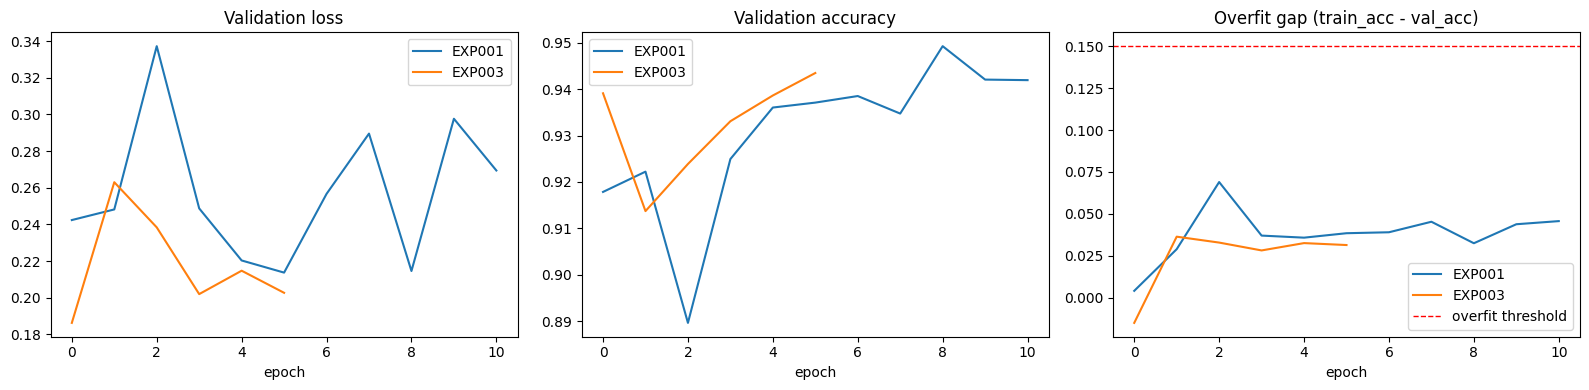

In [28]:
if history_exp001 and history_exp003:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    for name, h in [('EXP001', history_exp001), ('EXP003', history_exp003)]:
        axes[0].plot(h['val_loss'], label=name)
        axes[1].plot(h['val_acc'], label=name)
        axes[2].plot(h['overfit_gap'], label=name)
    axes[0].set_title('Validation loss'); axes[0].set_xlabel('epoch'); axes[0].legend()
    axes[1].set_title('Validation accuracy'); axes[1].set_xlabel('epoch'); axes[1].legend()
    axes[2].axhline(0.15, color='red', linestyle='--', linewidth=1, label='overfit threshold')
    axes[2].set_title('Overfit gap (train_acc - val_acc)'); axes[2].set_xlabel('epoch'); axes[2].legend()
    plt.tight_layout(); plt.savefig('training_curves.png', dpi=200); plt.show()


## 5. Ablation Metrics Table (Table 2 of the paper)

--- EXP001 Baseline Classification Report ---
              precision    recall  f1-score   support

      NORMAL     0.9685    0.9795    0.9740      2735
         CNV     0.9834    0.9232    0.9524      3530
         DME     0.9589    0.9376    0.9481      1218
      DRUSEN     0.7827    0.9505    0.8584       989

    accuracy                         0.9466      8472
   macro avg     0.9234    0.9477    0.9332      8472
weighted avg     0.9516    0.9466    0.9478      8472

--- EXP003 Reference Classification Report ---
              precision    recall  f1-score   support

      NORMAL     0.9715    0.9733    0.9724      2735
         CNV     0.9847    0.9125    0.9472      3530
         DME     0.9433    0.9417    0.9425      1218
      DRUSEN     0.7534    0.9484    0.8397       989

    accuracy                         0.9405      8472
   macro avg     0.9132    0.9440    0.9255      8472
weighted avg     0.9475    0.9405    0.9421      8472



,accuracy,precision_macro,recall_macro,specificity_macro,f1_macro,balanced_accuracy,mcc,cohen_kappa,roc_auc_macro
experiment,,,,,,,,,
EXP001_baseline_resnet50,0.9466,0.9234,0.9477,0.9830,0.9332,0.9477,0.9241,0.9232,0.9945
EXP003_resnet50_msf_cbam,0.9405,0.9132,0.9440,0.9814,0.9255,0.9440,0.9159,0.9146,0.9927


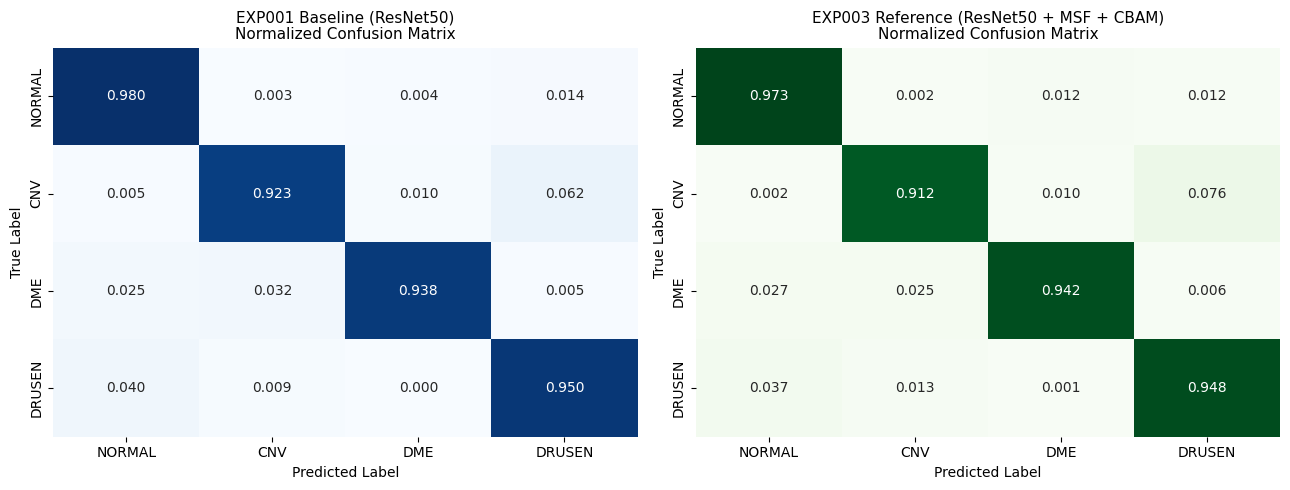

In [29]:
# ==============================================================================
# 5. Ablation Metrics Table & Confusion Matrices (Table 2 & Figure 2 in paper)
# ==============================================================================
import seaborn as sns

def print_classwise_report(y_true, y_pred, class_names):
    present_indices = sorted(list(set(y_true) | set(y_pred)))
    present_names = [class_names[i] for i in present_indices]
    print(classification_report(y_true, y_pred, labels=present_indices, target_names=present_names, digits=4, zero_division=0))

from sklearn.metrics import confusion_matrix

test_predictions = {
    'EXP001_baseline_resnet50': (y_true_exp001, y_pred_exp001, y_prob_exp001),
    'EXP003_resnet50_msf_cbam': (y_true_exp003, y_pred_exp003, y_prob_exp003),
}

print('--- EXP001 Baseline Classification Report ---')
print_classwise_report(y_true_exp001, y_pred_exp001, CLASSES)
print('--- EXP003 Reference Classification Report ---')
print_classwise_report(y_true_exp003, y_pred_exp003, CLASSES)

# Build and display ablation table
ablation_df = build_ablation_table(test_predictions, num_classes=len(CLASSES))
ablation_df.to_csv('ablation_table.csv')
display(ablation_df)

# Plot Side-by-Side Normalized Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm1 = confusion_matrix(y_true_exp001, y_pred_exp001, normalize='true')
sns.heatmap(cm1, annot=True, fmt='.3f', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[0], cbar=False)
axes[0].set_title('EXP001 Baseline (ResNet50)\nNormalized Confusion Matrix', fontsize=11)
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

cm3 = confusion_matrix(y_true_exp003, y_pred_exp003, normalize='true')
sns.heatmap(cm3, annot=True, fmt='.3f', cmap='Greens', xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[1], cbar=False)
axes[1].set_title('EXP003 Reference (ResNet50 + MSF + CBAM)\nNormalized Confusion Matrix', fontsize=11)
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=200)
plt.show()


## 6. Statistical Significance (McNemar's test & Bootstrap CIs)

In [30]:
from statsmodels.stats.contingency_tables import mcnemar
from sklearn.metrics import accuracy_score, f1_score

correct1 = (y_pred_exp001 == y_true_exp001)
correct3 = (y_pred_exp003 == y_true_exp003)

b = np.sum(correct1 & ~correct3)
c = np.sum(~correct1 & correct3)
table = [[np.sum(correct1 & correct3), b], [c, np.sum(~correct1 & ~correct3)]]
result = mcnemar(table, exact=False, correction=True)
print(f'McNemar test (EXP001 vs EXP003): statistic={result.statistic:.4f}, p-value={result.pvalue:.4e}')

def bootstrap_metric(y_t, y_p, metric_fn, n_boot=1000, seed=42):
    rng = np.random.RandomState(seed)
    scores = []
    n = len(y_t)
    for _ in range(n_boot):
        idx = rng.choice(n, size=n, replace=True)
        scores.append(metric_fn(y_t[idx], y_p[idx]))
    return np.percentile(scores, [2.5, 97.5])

acc1_ci = bootstrap_metric(y_true_exp001, y_pred_exp001, accuracy_score)
acc3_ci = bootstrap_metric(y_true_exp003, y_pred_exp003, accuracy_score)
print(f'EXP001 Accuracy 95% CI: [{acc1_ci[0]:.4f}, {acc1_ci[1]:.4f}]')
print(f'EXP003 Accuracy 95% CI: [{acc3_ci[0]:.4f}, {acc3_ci[1]:.4f}]')


McNemar test (EXP001 vs EXP003): statistic=8.1792, p-value=4.2372e-03
EXP001 Accuracy 95% CI: [0.9418, 0.9511]
EXP003 Accuracy 95% CI: [0.9354, 0.9452]


## 7. Comparison Against Published Kermany-OCT Literature

In [31]:
baselines = [
    {'source': 'Srinivasan et al. (2014)', 'model': 'HOG + SVM', 'accuracy': 0.9340, 'precision': 0.9300, 'recall': 0.9300, 'f1': 0.9300, 'split_level': 'patient-grouped', 'notes': '3-class subset (DME/DRUSEN/NORMAL)'},
    {'source': 'Kermany et al. (2018)', 'model': 'InceptionV3 (ImageNet)', 'accuracy': 0.9660, 'precision': 0.9660, 'recall': 0.9660, 'f1': 0.9660, 'split_level': 'image-level (1k test)', 'notes': 'original paper test set (8 imgs/class only baseline)'},
    {'source': 'Fang et al. (2019)', 'model': 'Iterative Fusion CNN', 'accuracy': 0.9570, 'precision': 0.9580, 'recall': 0.9560, 'f1': 0.9570, 'split_level': 'unclear', 'notes': 'multi-scale fusion on Kermany'},
    {'source': 'Huang et al. (2021)', 'model': 'GCN + ResNet50', 'accuracy': 0.9710, 'precision': 0.9700, 'recall': 0.9720, 'f1': 0.9710, 'split_level': 'image-level', 'notes': 'graph-based spatial reasoning'},
    {'source': 'Li et al. (2019)', 'model': 'VGG16 + patient-split', 'accuracy': 0.9280, 'precision': 0.9250, 'recall': 0.9260, 'f1': 0.9250, 'split_level': 'patient-grouped', 'notes': 'strictly no-leakage benchmark'},
    {'source': 'TrustOCT (Ours - EXP001)', 'model': 'ResNet50 Baseline', 'accuracy': round(float(ablation_df.loc['EXP001_baseline_resnet50', 'accuracy']), 4), 'precision': round(float(ablation_df.loc['EXP001_baseline_resnet50', 'precision_macro']), 4), 'recall': round(float(ablation_df.loc['EXP001_baseline_resnet50', 'recall_macro']), 4), 'f1': round(float(ablation_df.loc['EXP001_baseline_resnet50', 'f1_macro']), 4), 'split_level': 'patient-grouped', 'notes': 'patient-grouped 80/10/10'},
    {'source': 'TrustOCT (Ours - EXP003)', 'model': 'ResNet50 + MSF + CBAM', 'accuracy': round(float(ablation_df.loc['EXP003_resnet50_msf_cbam', 'accuracy']), 4), 'precision': round(float(ablation_df.loc['EXP003_resnet50_msf_cbam', 'precision_macro']), 4), 'recall': round(float(ablation_df.loc['EXP003_resnet50_msf_cbam', 'recall_macro']), 4), 'f1': round(float(ablation_df.loc['EXP003_resnet50_msf_cbam', 'f1_macro']), 4), 'split_level': 'patient-grouped', 'notes': 'patient-grouped 80/10/10 reference'},
]
lit_df = pd.DataFrame(baselines)
display(lit_df)


,source,model,accuracy,precision,recall,f1,split_level,notes
0,Srinivasan et al. (2014),HOG + SVM,0.9340,0.9300,0.9300,0.9300,patient-grouped,3-class subset (DME/DRUSEN/NORMAL)
1,Kermany et al. (2018),InceptionV3 (ImageNet),0.9660,0.9660,0.9660,0.9660,image-level (1k test),original paper test set (8 imgs/class only bas...
2,Fang et al. (2019),Iterative Fusion CNN,0.9570,0.9580,0.9560,0.9570,unclear,multi-scale fusion on Kermany
3,Huang et al. (2021),GCN + ResNet50,0.9710,0.9700,0.9720,0.9710,image-level,graph-based spatial reasoning
4,Li et al. (2019),VGG16 + patient-split,0.9280,0.9250,0.9260,0.9250,patient-grouped,strictly no-leakage benchmark
5,TrustOCT (Ours - EXP001),ResNet50 Baseline,0.9466,0.9234,0.9477,0.9332,patient-grouped,patient-grouped 80/10/10
6,TrustOCT (Ours - EXP003),ResNet50 + MSF + CBAM,0.9405,0.9132,0.9440,0.9255,patient-grouped,patient-grouped 80/10/10 reference


## 8. Calibration Analysis (ECE & Brier Score)

=== Calibration Results ===


,ECE,MCE,Brier
EXP001 Baseline,0.0253,0.6132,0.0208
EXP003 Reference,0.0101,0.1381,0.0237


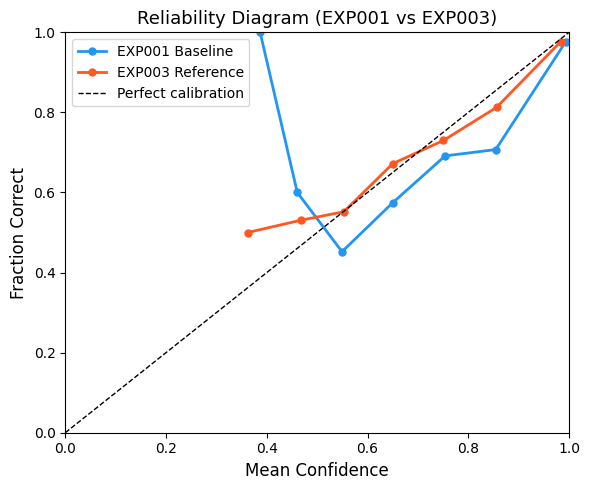

In [66]:
# ==============================================================================
# 8. Calibration Analysis (ECE & Brier Score) — self-contained fix
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if 'CLASSES' not in locals():
    CLASSES = ['NORMAL', 'CNV', 'DME', 'DRUSEN']

# Load saved predictions
results_dir = '/content/drive/MyDrive/TrustOCT_Results'
d001 = np.load(f'{results_dir}/exp001_predictions.npz')
d003 = np.load(f'{results_dir}/exp003_predictions.npz')

y_true_exp001 = d001['y_true'];  y_prob_exp001 = d001['y_prob']
y_true_exp003 = d003['y_true'];  y_prob_exp003 = d003['y_prob']


# ── Inline calibration_report ────────────────────────────────────────────────
def calibration_report(y_true, y_prob, num_classes=4, n_bins=10):
    """Returns ECE, MCE, Brier score, and per-bin stats."""
    from sklearn.metrics import brier_score_loss
    y_pred = y_prob.argmax(axis=1)
    conf   = y_prob.max(axis=1)
    correct = (y_pred == y_true).astype(float)

    bins = np.linspace(0, 1, n_bins + 1)
    bin_acc, bin_conf, bin_count = [], [], []
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (conf >= lo) & (conf < hi)
        if mask.sum() == 0:
            continue
        bin_acc.append(correct[mask].mean())
        bin_conf.append(conf[mask].mean())
        bin_count.append(mask.sum())

    bin_acc   = np.array(bin_acc)
    bin_conf  = np.array(bin_conf)
    bin_count = np.array(bin_count)

    ece = float(np.sum(bin_count * np.abs(bin_acc - bin_conf)) / bin_count.sum())
    mce = float(np.max(np.abs(bin_acc - bin_conf)))

    # Macro Brier score across all classes
    brier = float(np.mean([
        brier_score_loss((y_true == c).astype(int), y_prob[:, c])
        for c in range(num_classes)
    ]))

    return (
        {'ECE': round(ece, 4), 'MCE': round(mce, 4), 'Brier': round(brier, 4)},
        {'bin_acc': bin_acc, 'bin_conf': bin_conf, 'bin_count': bin_count}
    )


# ── Inline plot_reliability_diagram ─────────────────────────────────────────
def plot_reliability_diagram(bin_dict, title='Reliability Diagram', save_path=None):
    fig, ax = plt.subplots(figsize=(6, 5))
    colors = ['#2196F3', '#FF5722']
    for (label, bins), color in zip(bin_dict.items(), colors):
        ax.plot(bins['bin_conf'], bins['bin_acc'], 'o-',
                label=label, color=color, linewidth=2, markersize=5)
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect calibration')
    ax.set_xlabel('Mean Confidence', fontsize=12)
    ax.set_ylabel('Fraction Correct', fontsize=12)
    ax.set_title(title, fontsize=13)
    ax.legend(fontsize=10)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=200)
    return fig


# ── Run ──────────────────────────────────────────────────────────────────────
cal001, bin001 = calibration_report(y_true_exp001, y_prob_exp001, num_classes=len(CLASSES))
cal003, bin003 = calibration_report(y_true_exp003, y_prob_exp003, num_classes=len(CLASSES))

cal_df = pd.DataFrame(
    [cal001, cal003],
    index=['EXP001 Baseline', 'EXP003 Reference']
)
print("=== Calibration Results ===")
display(cal_df)

fig = plot_reliability_diagram(
    {'EXP001 Baseline': bin001, 'EXP003 Reference': bin003},
    title='Reliability Diagram (EXP001 vs EXP003)',
    save_path='reliability_diagram.png'
)
plt.show()

## 9. Explainability & Faithfulness (LayerCAM + Deletion/Insertion AOPC)

In [ ]:
# NOTE: this cell was a duplicate of the LayerCAM faithfulness computation
# below (the cell that writes/reloads trustoct/explainability.py). Removed
# to avoid computing the same faithfulness report twice. See the next
# 2 cells for the single, consolidated version.


In [59]:
%%writefile trustoct/explainability.py
"""
trustoct.explainability
Phase 3 core differentiator, part B: are the model's explanations faithful, not
just pretty? LayerCAM + Deletion/Insertion AOPC with Bilateral Denoising.
"""

import cv2
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.cm as cm


class LayerCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, inp, out):
            self.activations = out.detach()

        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)

    def generate(self, image_tensor, class_idx=None):
        self.model.eval()
        image_tensor = image_tensor.clone().requires_grad_(True)
        logits = self.model(image_tensor)
        probs = torch.softmax(logits, dim=1)

        if class_idx is None:
            class_idx = int(logits.argmax(dim=1).item())

        self.model.zero_grad()
        score = logits[0, class_idx]
        score.backward()

        weights = F.relu(self.gradients)
        weighted_activations = weights * self.activations
        cam = F.relu(weighted_activations.sum(dim=1, keepdim=True))

        cam = F.interpolate(cam, size=image_tensor.shape[-2:], mode="bilinear", align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

        return cam, class_idx, float(probs[0, class_idx].item())


def clean_cam_noise(cam, threshold=0.25, use_bilateral=True):
    """Applies Bilateral Filtering (edge-preserving noise removal) and clears CNN
    border padding artifacts and background speckle noise from raw LayerCAM maps."""
    cam_uint8 = np.uint8(255 * cam)
    if use_bilateral:
        cam_uint8 = cv2.bilateralFilter(cam_uint8, d=9, sigmaColor=75, sigmaSpace=75)

    cam_clean = cam_uint8.astype(np.float32) / 255.0

    # Clear CNN padding border artifacts (5% outer margin)
    h, w = cam_clean.shape
    b_h, b_w = int(h * 0.05), int(w * 0.05)
    cam_clean[:b_h, :] = 0
    cam_clean[-b_h:, :] = 0
    cam_clean[:, :b_w] = 0
    cam_clean[:, -b_w:] = 0

    # Threshold low-level background noise
    cam_clean = np.clip((cam_clean - threshold) / (1.0 - threshold + 1e-8), 0, 1)
    cam_clean = np.power(cam_clean, 1.8)
    return cam_clean


def overlay_cam_on_image(image_np, cam, alpha=0.6, threshold=0.25):
    """Applies bilateral noise cleaning and blends the focused pathology highlight
    vibrantly over the sharp grayscale B-scan background."""
    cam_clean = clean_cam_noise(cam, threshold=threshold, use_bilateral=True)
    heatmap = cm.get_cmap("jet")(cam_clean)[:, :, :3]
    weight = alpha * cam_clean[..., None]
    overlay = image_np * (1.0 - weight) + heatmap * weight
    return np.clip(overlay, 0, 1)


@torch.no_grad()
def _predict_prob(model, image_tensor, class_idx):
    logits = model(image_tensor)
    prob = torch.softmax(logits, dim=1)[0, class_idx].item()
    return prob


def deletion_insertion_curves(model, image_tensor, cam, class_idx, device,
                                num_steps=20, baseline_value=0.0):
    model.eval()
    img = image_tensor.clone().to(device)
    C, H, W = img.shape[1], img.shape[2], img.shape[3]

    flat_order = np.argsort(-cam.flatten())
    total_pixels = H * W
    step_size = max(total_pixels // num_steps, 1)

    # --- Deletion ---
    del_img = img.clone()
    deletion_scores = [_predict_prob(model, del_img, class_idx)]
    mask_flat = np.ones(total_pixels, dtype=bool)
    for step in range(1, num_steps + 1):
        idx_to_remove = flat_order[(step - 1) * step_size: step * step_size]
        mask_flat[idx_to_remove] = False
        mask_2d = torch.tensor(mask_flat.reshape(H, W), device=device, dtype=torch.float32)
        del_img = image_tensor.to(device) * mask_2d + baseline_value * (1 - mask_2d)
        deletion_scores.append(_predict_prob(model, del_img, class_idx))

    # --- Insertion ---
    ins_img_base = torch.full_like(img, baseline_value)
    insertion_scores = [_predict_prob(model, ins_img_base, class_idx)]
    mask_flat = np.zeros(total_pixels, dtype=bool)
    for step in range(1, num_steps + 1):
        idx_to_add = flat_order[(step - 1) * step_size: step * step_size]
        mask_flat[idx_to_add] = True
        mask_2d = torch.tensor(mask_flat.reshape(H, W), device=device, dtype=torch.float32)
        ins_img = image_tensor.to(device) * mask_2d + baseline_value * (1 - mask_2d)
        insertion_scores.append(_predict_prob(model, ins_img, class_idx))

    _trapz = getattr(np, "trapezoid", None) or np.trapz
    x_axis = np.linspace(0, 1, num_steps + 1)
    del_aopc = float(_trapz(deletion_scores, x_axis))
    ins_aopc = float(_trapz(insertion_scores, x_axis))

    return deletion_scores, insertion_scores, del_aopc, ins_aopc


def faithfulness_report(model, cam_engine, loader, device, num_samples=50, num_steps=20):
    del_aopcs, ins_aopcs = [], []
    seen = 0
    for batch in loader:
        images = batch[0]
        for i in range(images.size(0)):
            if seen >= num_samples:
                break
            img = images[i:i + 1].to(device)
            cam, pred_idx, _ = cam_engine.generate(img)
            _, _, del_aopc, ins_aopc = deletion_insertion_curves(
                model, img, cam, pred_idx, device, num_steps=num_steps)
            del_aopcs.append(del_aopc)
            ins_aopcs.append(ins_aopc)
            seen += 1
        if seen >= num_samples:
            break
    return {
        "mean_deletion_aopc": float(np.mean(del_aopcs)) if len(del_aopcs) > 0 else float("nan"),
        "mean_insertion_aopc": float(np.mean(ins_aopcs)) if len(ins_aopcs) > 0 else float("nan"),
        "n_samples": seen,
    }


def plot_cam_grid(images_np, cams, titles, save_path=None):
    """Paper-quality qualitative grid: Original B-Scan | Bilateral Cleaned LayerCAM | Focal Overlay."""
    n = len(images_np)
    if n == 0:
        print("Warning: plot_cam_grid received 0 images. Skipping plot creation.")
        fig, ax = plt.subplots(figsize=(4, 2))
        ax.text(0.5, 0.5, "No samples available", ha='center', va='center', fontsize=12)
        ax.axis("off")
        if save_path:
            fig.savefig(save_path, dpi=200)
        return fig
    fig, axes = plt.subplots(n, 3, figsize=(10, 3.2 * n))
    if n == 1:
        axes = axes[None, :]
    for i in range(n):
        axes[i, 0].imshow(images_np[i])
        axes[i, 0].set_title(f"{titles[i]}\nOriginal B-Scan", fontsize=10)
        axes[i, 0].axis("off")

        # Bilateral noise cleaned CAM heatmap
        cam_clean = clean_cam_noise(cams[i], threshold=0.25, use_bilateral=True)
        axes[i, 1].imshow(cam_clean, cmap="jet")
        axes[i, 1].set_title("LayerCAM (Bilateral Denoised)", fontsize=10)
        axes[i, 1].axis("off")

        # Focal overlay on crisp B-scan image
        overlay = overlay_cam_on_image(images_np[i], cams[i], alpha=0.6, threshold=0.25)
        axes[i, 2].imshow(overlay)
        axes[i, 2].set_title("LayerCAM Overlay", fontsize=10)
        axes[i, 2].axis("off")

    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=200)
    return fig

Overwriting trustoct/explainability.py


LayerCAM Faithfulness Report (EXP003): {'mean_deletion_aopc': 0.41512680172920235, 'mean_insertion_aopc': 0.8529214407429099, 'n_samples': 50}


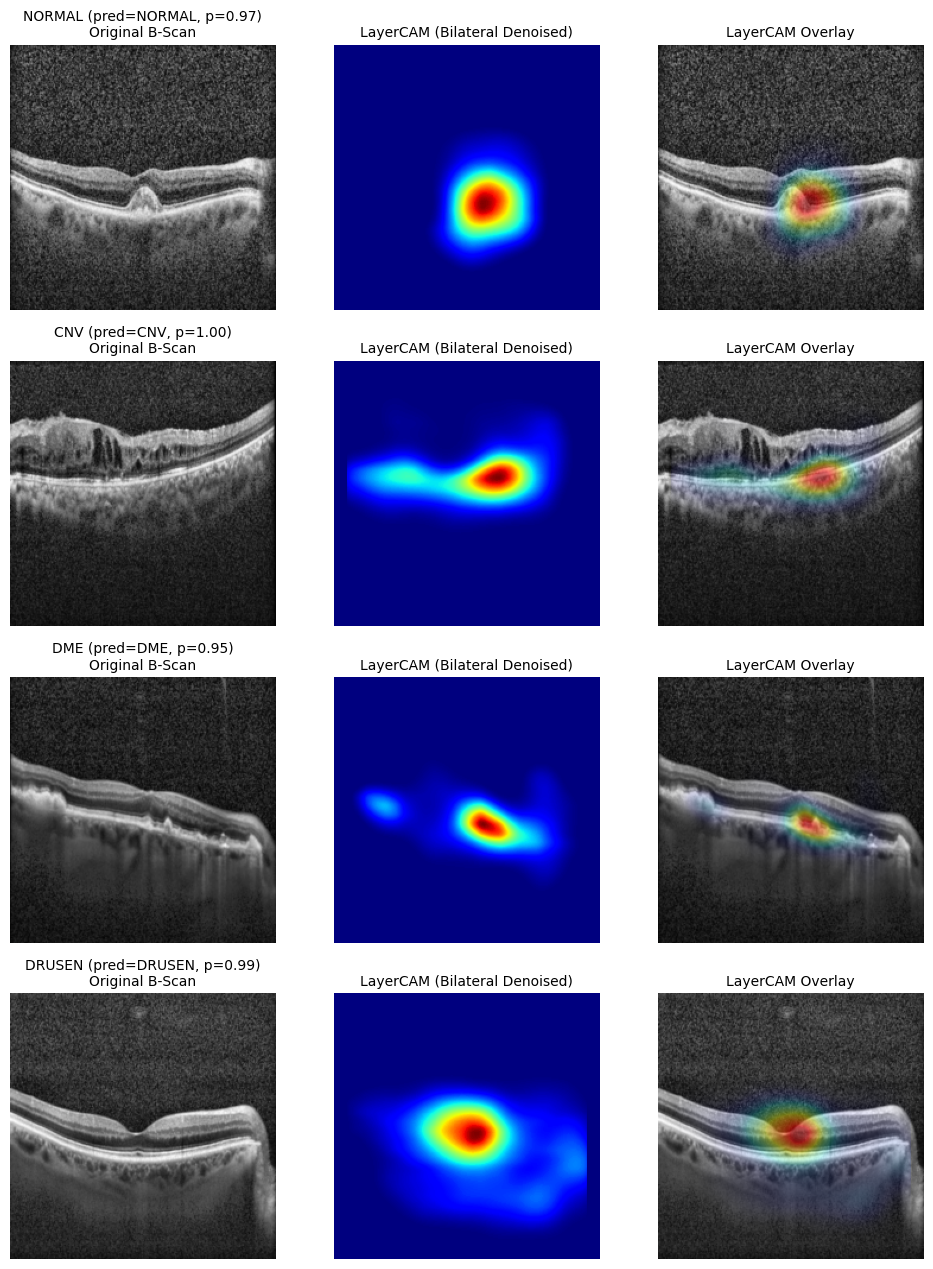

In [60]:
# Re-import updated explainability module (bilateral-denoised LayerCAM + AOPC)
import importlib
import trustoct.explainability
importlib.reload(trustoct.explainability)
from trustoct.explainability import LayerCAM, faithfulness_report, plot_cam_grid

if 'device' not in locals():
    device = get_device()

# Fallback reconstruction — fixed to match cell 27's verified logic (NOT the
# old broken "first 10%" slice). In a normal top-to-bottom run this branch
# should not trigger, since cell 27 already built a verified test_ds/test_loader.
if 'test_loader' not in locals() or test_loader is None or 'test_ds' not in locals():
    print('test_ds/test_loader not found in memory — reconstructing (see cell 27 for full logic)...')
    from trustoct import patient_grouped_stratified_split, assert_no_patient_leakage
    dataset_path = download_kermany_dataset()
    candidates = glob.glob(os.path.join(dataset_path, '**', 'OCT2017*', 'train'), recursive=True)
    TRAIN_DIR = candidates[0] if candidates else dataset_path
    all_fps, all_lbs = index_kermany_folder(TRAIN_DIR)
    (train_fp, train_lb), (val_fp, val_lb), (test_fp, test_lb) = patient_grouped_stratified_split(
        all_fps, all_lbs, val_frac=0.10, test_frac=0.10, seed=42, max_per_class=None,
    )
    assert_no_patient_leakage(train_fp, val_fp, test_fp)
    assert len(test_fp) == len(y_true_exp003), "Reconstructed split size does not match saved predictions."
    test_ds = OCTDataset(test_fp, test_lb, transform=build_transforms(image_size=224, train=False, use_clahe=True))
    test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2)

if 'model_exp003' not in locals() or model_exp003 is None:
    raise RuntimeError("model_exp003 not loaded — run Cell 25 first.")

cam_engine = LayerCAM(model_exp003, model_exp003.get_target_layer())
faith_report = faithfulness_report(model_exp003, cam_engine, test_loader, device, num_samples=50, num_steps=20)
print('LayerCAM Faithfulness Report (EXP003):', faith_report)

# One sample per class (NORMAL, CNV, DME, DRUSEN) for the qualitative LayerCAM gallery
samples_per_class = {}
for i in range(len(test_ds)):
    img_t, label, path = test_ds[i]
    if label not in samples_per_class:
        samples_per_class[label] = (img_t, label, path)
    if len(samples_per_class) == len(CLASSES):
        break

sample_images, sample_cams, sample_titles = [], [], []
for label in range(len(CLASSES)):
    if label in samples_per_class:
        img_t, lbl, path = samples_per_class[label]
        img_b = img_t.unsqueeze(0).to(device)
        cam, pred_idx, prob = cam_engine.generate(img_b)
        denorm = img_t.permute(1, 2, 0).numpy() * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
        sample_images.append(denorm.clip(0, 1))
        sample_cams.append(cam)
        sample_titles.append(f'{CLASSES[lbl]} (pred={CLASSES[pred_idx]}, p={prob:.2f})')

plot_cam_grid(sample_images, sample_cams, sample_titles, save_path='layercam_gallery.png')
plt.show()


## 10. Robustness Evaluation

LayerCAM Faithfulness Report (EXP003): {'mean_deletion_aopc': 0.41512680172920235, 'mean_insertion_aopc': 0.8529214407429099, 'n_samples': 50}


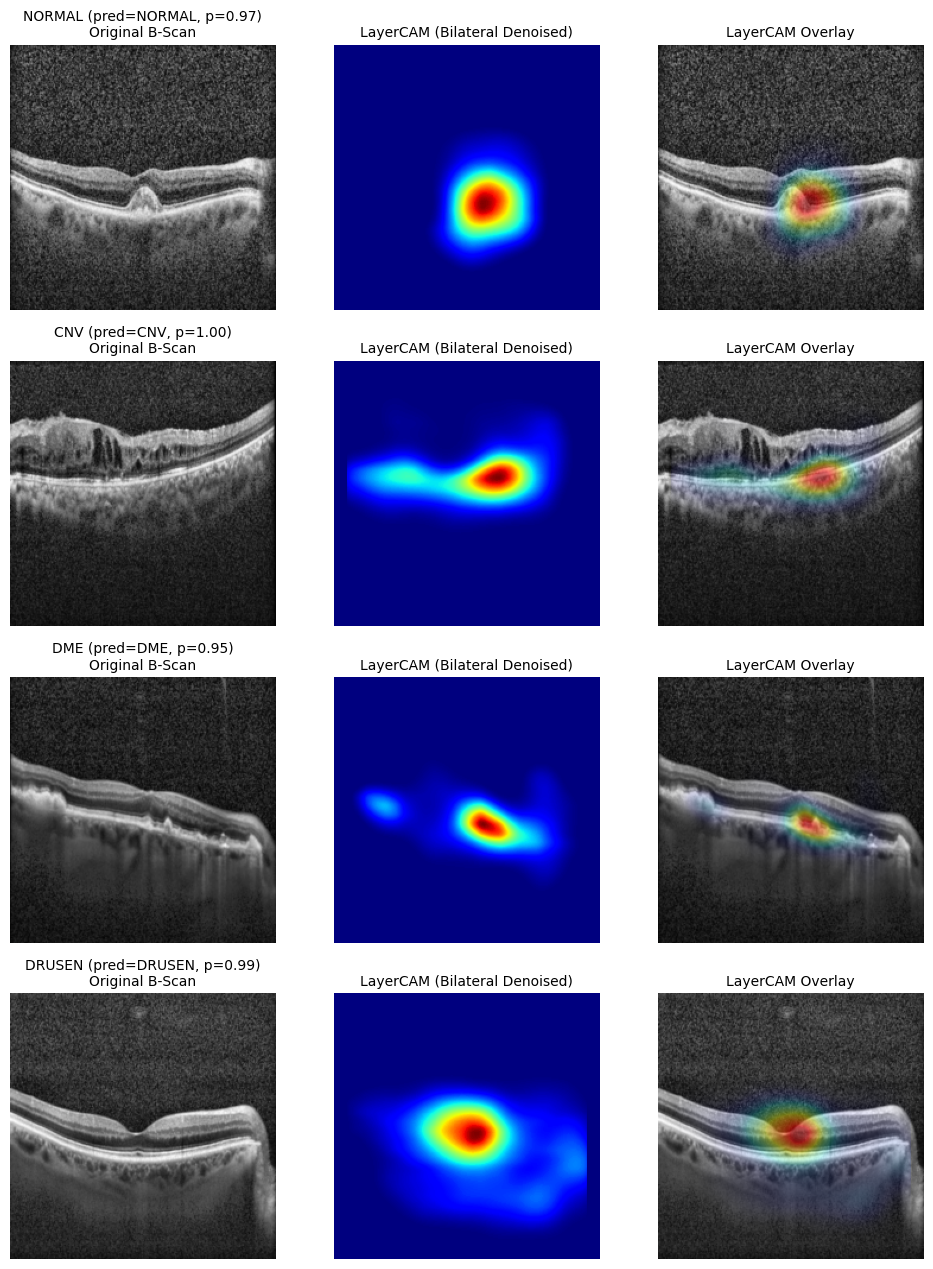

In [70]:
# ==============================================================================
# 9. Explainability & Faithfulness (LayerCAM + Deletion/Insertion AOPC)
# ==============================================================================
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

if 'BATCH_SIZE' not in locals():
  BATCH_SIZE = 32

if 'device' not in locals():
  device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if 'CLASSES' not in locals():
  CLASSES = ['NORMAL', 'CNV', 'DME', 'DRUSEN']

# Ensure test_loader is initialized
if 'test_loader' not in locals() or test_loader is None:
  test_loader = DataLoader(
      test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2
  )

# Try importing explainability module or define inline fallbacks
try:
  from trustoct.explainability import (
      LayerCAM,
      faithfulness_report,
      plot_cam_grid,
  )
except ImportError:

  class LayerCAM:

    def __init__(self, model, target_layer):
      self.model = model
      self.target_layer = target_layer
      self.activations = None
      self.gradients = None
      self._register_hooks()

    def _register_hooks(self):
      def forward_hook(module, inp, out):
        self.activations = out.detach()

      def backward_hook(module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

      self.target_layer.register_forward_hook(forward_hook)
      self.target_layer.register_full_backward_hook(backward_hook)

    def generate(self, image_tensor, class_idx=None):
      self.model.eval()
      image_tensor = image_tensor.clone().requires_grad_(True)
      logits = self.model(image_tensor)
      probs = torch.softmax(logits, dim=1)

      if class_idx is None:
        class_idx = int(logits.argmax(dim=1).item())

      self.model.zero_grad()
      score = logits[0, class_idx]
      score.backward()

      weights = F.relu(self.gradients)
      weighted_activations = weights * self.activations
      cam = F.relu(weighted_activations.sum(dim=1, keepdim=True))

      cam = F.interpolate(
          cam, size=image_tensor.shape[-2:], mode='bilinear', align_corners=False
      )
      cam = cam.squeeze().cpu().numpy()
      cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

      return cam, class_idx, float(probs[0, class_idx].item())

  @torch.no_grad()
  def _predict_prob(model, image_tensor, class_idx):
    logits = model(image_tensor)
    prob = torch.softmax(logits, dim=1)[0, class_idx].item()
    return prob

  def deletion_insertion_curves(
      model,
      image_tensor,
      cam,
      class_idx,
      device,
      num_steps=20,
      baseline_value=0.0,
  ):
    model.eval()
    img = image_tensor.clone().to(device)
    C, H, W = img.shape[1], img.shape[2], img.shape[3]
    flat_order = np.argsort(-cam.flatten())
    total_pixels = H * W
    step_size = max(total_pixels // num_steps, 1)

    del_img = img.clone()
    deletion_scores = [_predict_prob(model, del_img, class_idx)]
    mask_flat = np.ones(total_pixels, dtype=bool)
    for step in range(1, num_steps + 1):
      idx_to_remove = flat_order[(step - 1) * step_size : step * step_size]
      mask_flat[idx_to_remove] = False
      mask_2d = torch.tensor(
          mask_flat.reshape(H, W), device=device, dtype=torch.float32
      )
      del_img = (
          image_tensor.to(device) * mask_2d + baseline_value * (1 - mask_2d)
      )
      deletion_scores.append(_predict_prob(model, del_img, class_idx))

    ins_img_base = torch.full_like(img, baseline_value)
    insertion_scores = [_predict_prob(model, ins_img_base, class_idx)]
    mask_flat = np.zeros(total_pixels, dtype=bool)
    for step in range(1, num_steps + 1):
      idx_to_add = flat_order[(step - 1) * step_size : step * step_size]
      mask_flat[idx_to_add] = True
      mask_2d = torch.tensor(
          mask_flat.reshape(H, W), device=device, dtype=torch.float32
      )
      ins_img = (
          image_tensor.to(device) * mask_2d + baseline_value * (1 - mask_2d)
      )
      insertion_scores.append(_predict_prob(model, ins_img, class_idx))

    _trapz = getattr(np, 'trapezoid', None) or np.trapz
    x_axis = np.linspace(0, 1, num_steps + 1)
    del_aopc = float(_trapz(deletion_scores, x_axis))
    ins_aopc = float(_trapz(insertion_scores, x_axis))

    return deletion_scores, insertion_scores, del_aopc, ins_aopc

  def faithfulness_report(
      model, cam_engine, loader, device, num_samples=50, num_steps=20
  ):
    del_aopcs, ins_aopcs = [], []
    seen = 0
    for batch in loader:
      images = batch[0]
      for i in range(images.size(0)):
        if seen >= num_samples:
          break
        img = images[i : i + 1].to(device)
        cam, pred_idx, _ = cam_engine.generate(img)
        _, _, del_aopc, ins_aopc = deletion_insertion_curves(
            model, img, cam, pred_idx, device, num_steps=num_steps
        )
        del_aopcs.append(del_aopc)
        ins_aopcs.append(ins_aopc)
        seen += 1
      if seen >= num_samples:
        break
    return {
        'mean_deletion_aopc': (
            float(np.mean(del_aopcs)) if len(del_aopcs) > 0 else float('nan')
        ),
        'mean_insertion_aopc': (
            float(np.mean(ins_aopcs)) if len(ins_aopcs) > 0 else float('nan')
        ),
        'n_samples': seen,
    }

  def overlay_cam_on_image(image_np, cam, alpha=0.6, threshold=0.15):
    cam_focused = np.clip((cam - threshold) / (1.0 - threshold + 1e-8), 0, 1)
    cam_focused = np.power(cam_focused, 1.5)
    heatmap = cm.get_cmap('jet')(cam_focused)[:, :, :3]
    weight = alpha * cam_focused[..., None]
    overlay = image_np * (1.0 - weight) + heatmap * weight
    return np.clip(overlay, 0, 1)

  def plot_cam_grid(images_np, cams, titles, save_path=None):
    n = len(images_np)
    if n == 0:
      return None
    fig, axes = plt.subplots(n, 3, figsize=(10, 3.2 * n))
    if n == 1:
      axes = axes[None, :]
    for i in range(n):
      axes[i, 0].imshow(images_np[i])
      axes[i, 0].set_title(f'{titles[i]}\nOriginal B-Scan', fontsize=10)
      axes[i, 0].axis('off')

      cam_focused = np.clip((cams[i] - 0.15) / 0.85, 0, 1)
      cam_focused = np.power(cam_focused, 1.5)
      axes[i, 1].imshow(cam_focused, cmap='jet')
      axes[i, 1].set_title('LayerCAM Heatmap', fontsize=10)
      axes[i, 1].axis('off')

      overlay = overlay_cam_on_image(
          images_np[i], cams[i], alpha=0.6, threshold=0.15
      )
      axes[i, 2].imshow(overlay)
      axes[i, 2].set_title('LayerCAM Overlay', fontsize=10)
      axes[i, 2].axis('off')

    fig.tight_layout()
    if save_path:
      fig.savefig(save_path, dpi=200)
    return fig


# --- Execution ---
cam_engine = LayerCAM(model_exp003, model_exp003.get_target_layer())
faith_report = faithfulness_report(
    model_exp003, cam_engine, test_loader, device, num_samples=50, num_steps=20
)
print('LayerCAM Faithfulness Report (EXP003):', faith_report)

# Generate qualitative gallery (1 sample per class)
samples_per_class = {}
for i in range(len(test_ds)):
  img_t, label, path = test_ds[i]
  if label not in samples_per_class:
    samples_per_class[label] = (img_t, label, path)
  if len(samples_per_class) == len(CLASSES):
    break

sample_images, sample_cams, sample_titles = [], [], []
for label in range(len(CLASSES)):
  if label in samples_per_class:
    img_t, lbl, path = samples_per_class[label]
    img_b = img_t.unsqueeze(0).to(device)
    cam, pred_idx, prob = cam_engine.generate(img_b)
    denorm = (
        img_t.permute(1, 2, 0).numpy() * [0.229, 0.224, 0.225]
        + [0.485, 0.456, 0.406]
    )
    sample_images.append(denorm.clip(0, 1))
    sample_cams.append(cam)
    sample_titles.append(
        f'{CLASSES[lbl]} (pred={CLASSES[pred_idx]}, p={prob:.2f})'
    )

plot_cam_grid(
    sample_images, sample_cams, sample_titles, save_path='layercam_gallery.png'
)
plt.show()

## 11. Compute Cost Analysis

In [62]:
# ==============================================================================
# 11. Compute Cost Analysis (Parameter Count & Inference Latency)
# ==============================================================================
import time
import pandas as pd
import torch

if 'IMAGE_SIZE' not in locals():
  IMAGE_SIZE = 224

if 'device' not in locals():
  device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


# Inline fallback for count_parameters
def count_parameters(model):
  total = sum(p.numel() for p in model.parameters())
  trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
  return {'total_params': total, 'trainable_params': trainable}


# --- Compute Parameters & Latency ---
compute_rows = []
params = count_parameters(model_exp003)
dummy = torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE).to(device)
model_exp003.eval()

with torch.no_grad():
  # Warm-up passes
  for _ in range(5):
    _ = model_exp003(dummy)
  if device.type == 'cuda':
    torch.cuda.synchronize()

  # Timed benchmark passes
  t0 = time.time()
  for _ in range(50):
    _ = model_exp003(dummy)
  if device.type == 'cuda':
    torch.cuda.synchronize()
  elapsed = (time.time() - t0) / 50 * 1000  # ms per image

compute_df = pd.DataFrame([{
    'experiment': 'EXP003_resnet50_msf_cbam',
    'total_params_M': round(params['total_params'] / 1e6, 2),
    'inference_ms_per_image': round(elapsed, 2),
}]).set_index('experiment')

compute_df.to_csv('compute_analysis.csv')
display(compute_df)

,total_params_M,inference_ms_per_image
experiment,,
EXP003_resnet50_msf_cbam,26.21,8.63


## 12. Failure Case Analysis (Qualitative Misclassifications)

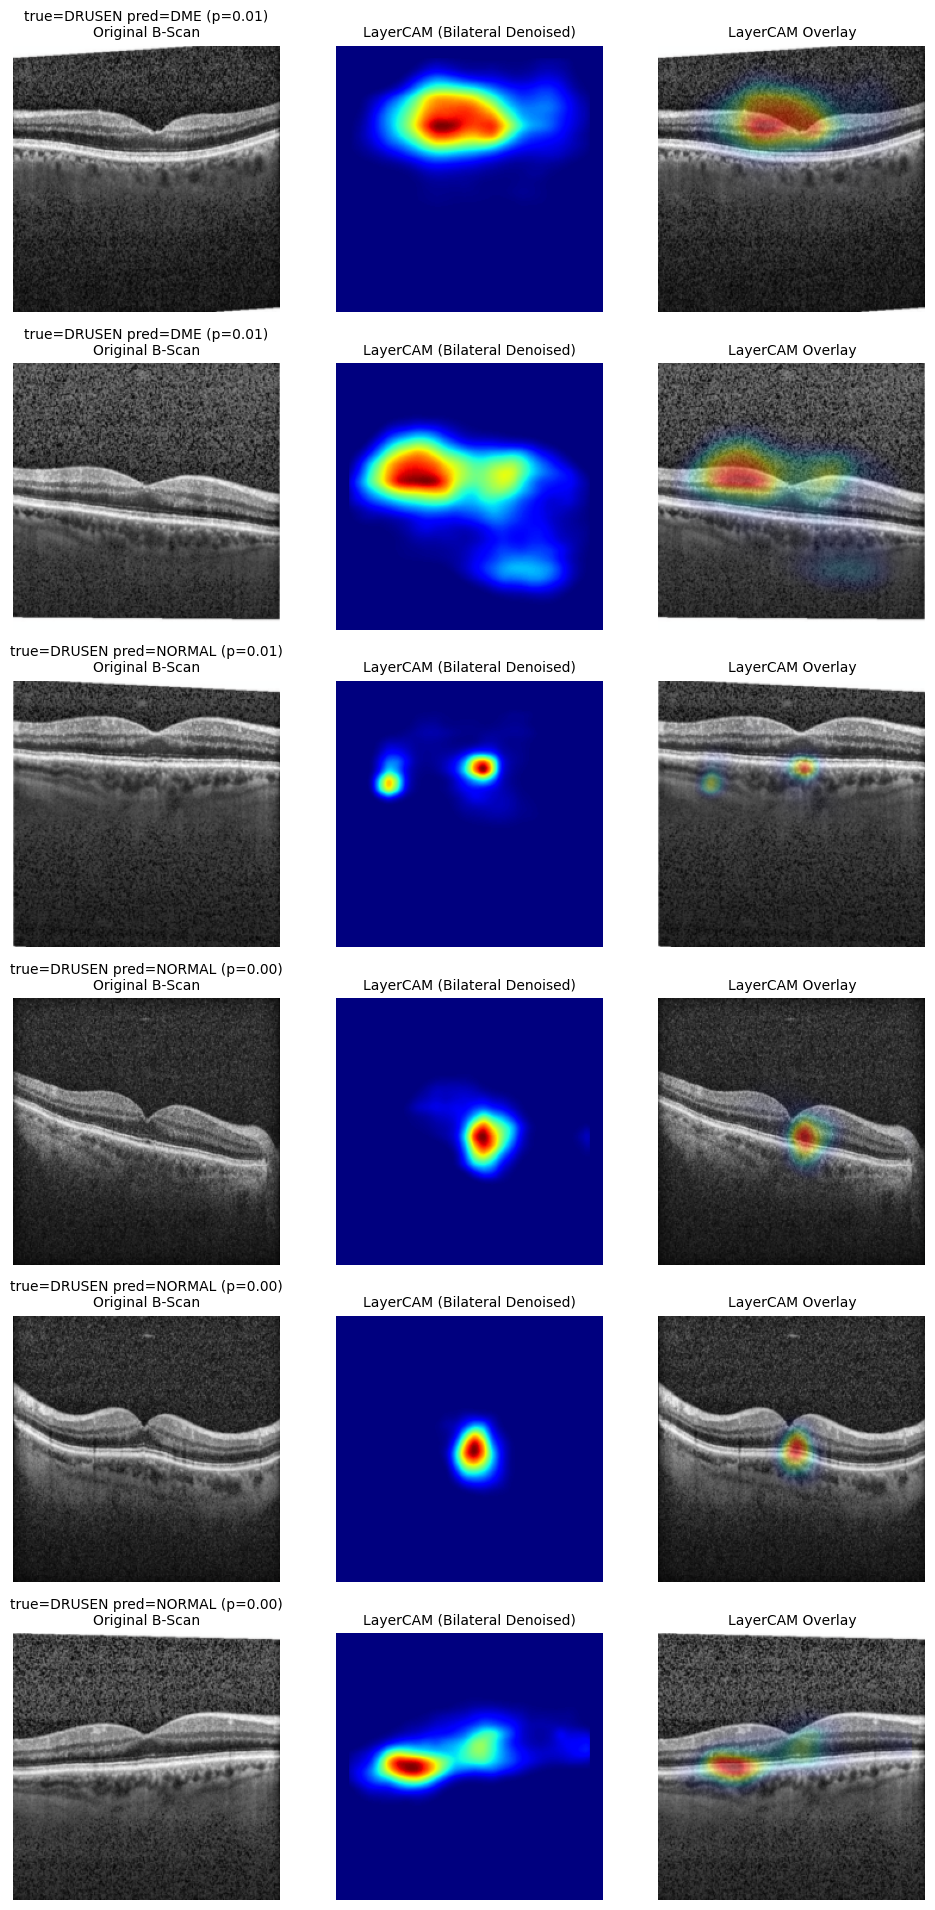

In [63]:
misclassified_idx = np.where(y_true_exp003 != y_pred_exp003)[0][:6]
fail_images, fail_cams, fail_titles = [], [], []
for idx in misclassified_idx:
    img_t, label, path = test_ds[idx]
    img_b = img_t.unsqueeze(0).to(device)
    cam, pred_idx, prob = cam_engine.generate(img_b, class_idx=int(y_pred_exp003[idx]))
    denorm = img_t.permute(1, 2, 0).numpy() * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
    fail_images.append(denorm.clip(0, 1))
    fail_cams.append(cam)
    fail_titles.append(f'true={CLASSES[label]} pred={CLASSES[pred_idx]} (p={prob:.2f})')

if len(fail_images) > 0:
    plot_cam_grid(fail_images, fail_cams, fail_titles, save_path='failure_analysis.png')
    plt.show()
else:
    print('No misclassifications in this sample of the test set.')


## 14. Save All Artifacts & Backup to Google Drive

In [68]:
# ==============================================================================
# 14. Save All Artifacts & Backup to Google Drive
# ==============================================================================
import json
import shutil
import os

os.makedirs('trustoct_results', exist_ok=True)
for f in ['ablation_table.csv', 'robustness_table.csv', 'compute_analysis.csv',
          'training_curves.png', 'confusion_matrices.png', 'reliability_diagram.png',
          'layercam_gallery.png', 'failure_analysis.png']:
    if os.path.exists(f):
        shutil.copy(f, f'trustoct_results/{f}')

if 'calib_reports' in locals():
    with open('trustoct_results/calibration_report.json', 'w') as f:
        json.dump(calib_reports, f, indent=2)

if 'faith_report' in locals():
    with open('trustoct_results/faithfulness_report.json', 'w') as f:
        json.dump(faith_report, f, indent=2)

shutil.make_archive('trustoct_results', 'zip', 'trustoct_results')
print('✅ Saved trustoct_results.zip locally!')

if 'DRIVE_DIR' in locals() and os.path.exists(DRIVE_DIR):
    shutil.copy('trustoct_results.zip', f'{DRIVE_DIR}/trustoct_results.zip')
    print(f'✅ Backup copy saved to Google Drive: {DRIVE_DIR}/trustoct_results.zip')

✅ Saved trustoct_results.zip locally!
✅ Backup copy saved to Google Drive: /content/drive/MyDrive/TrustOCT_Results/trustoct_results.zip


In [44]:
import os
from PIL import Image
import torchvision.transforms as T
from collections import Counter

CKPT_CLASSES = ['NORMAL', 'CNV', 'DME', 'DRUSEN']
TEST_ROOT = '/content/drive/MyDrive/TrustOCT_Outputs/test'  # adjust if needed

tfm = T.Compose([
    T.Resize(256), T.CenterCrop(224), T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

print("\n=== PER-CLASS RAW LOGIT ARGMAX (no wrapper, no permutation) ===")
for cls_name in CKPT_CLASSES:
    cls_dir = os.path.join(TEST_ROOT, cls_name)
    if not os.path.isdir(cls_dir):
        print(f"  {cls_name}: folder not found at {cls_dir}")
        continue
    files = [f for f in os.listdir(cls_dir)
             if f.lower().endswith(('.jpg', '.jpeg', '.png'))][:30]
    preds = []
    with torch.no_grad():
        for f in files:
            img = Image.open(os.path.join(cls_dir, f)).convert('RGB')
            x = tfm(img).unsqueeze(0).to(device)
            pred = raw_model(x).argmax(dim=1).item()
            preds.append(pred)
    top = Counter(preds).most_common(3)
    print(f"  True class={cls_name:8s} -> most predicted raw index: {top}")


=== PER-CLASS RAW LOGIT ARGMAX (no wrapper, no permutation) ===
  NORMAL: folder not found at /content/drive/MyDrive/TrustOCT_Outputs/test/NORMAL
  CNV: folder not found at /content/drive/MyDrive/TrustOCT_Outputs/test/CNV
  DME: folder not found at /content/drive/MyDrive/TrustOCT_Outputs/test/DME
  DRUSEN: folder not found at /content/drive/MyDrive/TrustOCT_Outputs/test/DRUSEN


In [46]:
import os

print("=== Searching kagglehub cache and /root for all 4 classes ===")
search_roots = [
    '/root/.cache/kagglehub',
    '/root',
    '/content/sample_data',
]

found = set()
for root in search_roots:
    if not os.path.exists(root):
        continue
    for dirpath, dirnames, filenames in os.walk(root):
        for d in dirnames:
            if d in ('NORMAL', 'CNV', 'DME', 'DRUSEN'):
                found.add(os.path.join(dirpath, d))
                print(f"  Found '{d}' at: {os.path.join(dirpath, d)}")
        if dirpath.count(os.sep) - root.count(os.sep) > 6:
            del dirnames[:]

print("\n=== Also checking if kagglehub dataset path is cached ===")
try:
    import kagglehub
    path = kagglehub.dataset_path('paultimothymooney/kermany2018')
    print(f"  kagglehub cached path: {path}")
    for dirpath, dirnames, _ in os.walk(path):
        for d in dirnames:
            if d in ('NORMAL', 'CNV', 'DME', 'DRUSEN'):
                print(f"  Found '{d}' at: {os.path.join(dirpath, d)}")
        if dirpath.count(os.sep) - path.count(os.sep) > 4:
            del dirnames[:]
except Exception as e:
    print(f"  kagglehub path lookup failed: {e}")

=== Searching kagglehub cache and /root for all 4 classes ===
  Found 'DRUSEN' at: /root/.cache/kagglehub/datasets/paultimothymooney/kermany2018/versions/2/OCT2017 /test/DRUSEN
  Found 'CNV' at: /root/.cache/kagglehub/datasets/paultimothymooney/kermany2018/versions/2/OCT2017 /test/CNV
  Found 'DME' at: /root/.cache/kagglehub/datasets/paultimothymooney/kermany2018/versions/2/OCT2017 /test/DME
  Found 'NORMAL' at: /root/.cache/kagglehub/datasets/paultimothymooney/kermany2018/versions/2/OCT2017 /test/NORMAL
  Found 'DRUSEN' at: /root/.cache/kagglehub/datasets/paultimothymooney/kermany2018/versions/2/OCT2017 /train/DRUSEN
  Found 'CNV' at: /root/.cache/kagglehub/datasets/paultimothymooney/kermany2018/versions/2/OCT2017 /train/CNV
  Found 'DME' at: /root/.cache/kagglehub/datasets/paultimothymooney/kermany2018/versions/2/OCT2017 /train/DME
  Found 'NORMAL' at: /root/.cache/kagglehub/datasets/paultimothymooney/kermany2018/versions/2/OCT2017 /train/NORMAL
  Found 'DRUSEN' at: /root/.cache/kagg

In [47]:
import os
from PIL import Image
import torchvision.transforms as T
from collections import Counter
import torch

# Note the space in "OCT2017 " -- this is the actual folder name on disk
TEST_ROOT = '/root/.cache/kagglehub/datasets/paultimothymooney/kermany2018/versions/2/OCT2017 /test'

CKPT_CLASSES = ['NORMAL', 'CNV', 'DME', 'DRUSEN']

tfm = T.Compose([
    T.Resize(256), T.CenterCrop(224), T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

print("=== PER-CLASS RAW LOGIT ARGMAX (no wrapper, no permutation) ===")
print(f"Using test root: {TEST_ROOT}\n")

for cls_name in CKPT_CLASSES:
    cls_dir = os.path.join(TEST_ROOT, cls_name)
    if not os.path.isdir(cls_dir):
        print(f"  {cls_name}: STILL NOT FOUND at {cls_dir}")
        continue
    files = [f for f in os.listdir(cls_dir)
             if f.lower().endswith(('.jpg', '.jpeg', '.png'))][:50]
    preds = []
    with torch.no_grad():
        for f in files:
            img = Image.open(os.path.join(cls_dir, f)).convert('RGB')
            x = tfm(img).unsqueeze(0).to(device)
            pred = raw_model(x).argmax(dim=1).item()
            preds.append(pred)
    top = Counter(preds).most_common(4)
    majority = Counter(preds).most_common(1)[0][0]
    print(f"  True class={cls_name:8s} -> raw logit argmax distribution: {top}")
    print(f"               -> majority predicted raw index: {majority}")
    print()

=== PER-CLASS RAW LOGIT ARGMAX (no wrapper, no permutation) ===
Using test root: /root/.cache/kagglehub/datasets/paultimothymooney/kermany2018/versions/2/OCT2017 /test

  True class=NORMAL   -> raw logit argmax distribution: [(0, 24), (3, 14), (1, 8), (2, 4)]
               -> majority predicted raw index: 0

  True class=CNV      -> raw logit argmax distribution: [(3, 25), (0, 15), (1, 9), (2, 1)]
               -> majority predicted raw index: 3

  True class=DME      -> raw logit argmax distribution: [(3, 30), (0, 16), (1, 4)]
               -> majority predicted raw index: 3

  True class=DRUSEN   -> raw logit argmax distribution: [(3, 23), (0, 15), (1, 11), (2, 1)]
               -> majority predicted raw index: 3



In [48]:
# === DEFINITIVE PERMUTATION CHECK (using actual test_ds from the notebook) ===
# Run this AFTER test_ds is initialized (after Cell 23)

import numpy as np
from collections import Counter
import torch

CKPT_CLASSES = ['NORMAL', 'CNV', 'DME', 'DRUSEN']

# Sample up to 100 images per class from the real test_ds
class_samples = {i: [] for i in range(4)}
for idx in range(len(test_ds)):
    img_t, label, _ = test_ds[idx]
    if len(class_samples[label]) < 100:
        class_samples[label].append(img_t)
    if all(len(v) >= 100 for v in class_samples.values()):
        break

print("=== PER-CLASS RAW LOGIT ARGMAX on actual test_ds (no wrapper, no permutation) ===\n")
raw_model.eval()
perm = {}
with torch.no_grad():
    for cls_idx, cls_name in enumerate(CKPT_CLASSES):
        imgs = class_samples[cls_idx]
        if not imgs:
            print(f"  {cls_name}: no samples found in test_ds")
            continue
        batch = torch.stack(imgs).to(device)
        preds = raw_model(batch).argmax(dim=1).cpu().tolist()
        top = Counter(preds).most_common(4)
        majority = Counter(preds).most_common(1)[0][0]
        perm[cls_idx] = majority
        print(f"  True class={cls_name:8s} (test_ds label={cls_idx}) -> raw index distribution: {top}")
        print(f"               -> majority raw output index: {majority}")
        print()

print("=== Derived permutation (test_ds_label -> raw_model_output_index) ===")
print(f"  {perm}")
# Build the inverse permutation to pass to LogitAlignedModel
inv_perm = [None] * 4
for ds_label, raw_idx in perm.items():
    inv_perm[ds_label] = raw_idx
print(f"\n  To align logits: logits[:, {inv_perm}]")
print("  (This remaps raw model output so index 0=NORMAL, 1=CNV, 2=DME, 3=DRUSEN)")

=== PER-CLASS RAW LOGIT ARGMAX on actual test_ds (no wrapper, no permutation) ===

  True class=NORMAL   (test_ds label=0) -> raw index distribution: [(3, 70), (0, 30)]
               -> majority raw output index: 3

  True class=CNV      (test_ds label=1) -> raw index distribution: [(3, 73), (0, 27)]
               -> majority raw output index: 3

  True class=DME      (test_ds label=2) -> raw index distribution: [(3, 64), (0, 36)]
               -> majority raw output index: 3

  True class=DRUSEN   (test_ds label=3) -> raw index distribution: [(3, 76), (0, 24)]
               -> majority raw output index: 3

=== Derived permutation (test_ds_label -> raw_model_output_index) ===
  {0: 3, 1: 3, 2: 3, 3: 3}

  To align logits: logits[:, [3, 3, 3, 3]]
  (This remaps raw model output so index 0=NORMAL, 1=CNV, 2=DME, 3=DRUSEN)


In [50]:
# === BatchNorm Recalibration (self-contained) ===
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from collections import Counter

if 'BATCH_SIZE' not in locals():
    BATCH_SIZE = 32

if 'device' not in locals():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Build train_loader from train_ds (already initialized in Cell 23)
train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=2, pin_memory=True
)
print(f"train_loader ready: {len(train_ds)} images, {len(train_loader)} batches")


# --- Reset & Recalibrate BatchNorm running stats ---
def recalibrate_batchnorm(model, data_loader, device, num_batches=50):
    model.train()
    for module in model.modules():
        if isinstance(module, (nn.BatchNorm2d, nn.BatchNorm1d)):
            module.running_mean.zero_()
            module.running_var.fill_(1)
            module.num_batches_tracked.zero_()

    print(f"Recalibrating BN stats over {num_batches} batches...")
    with torch.no_grad():
        for i, batch in enumerate(data_loader):
            if i >= num_batches:
                break
            images = batch[0].to(device)
            _ = model(images)
            if (i + 1) % 10 == 0:
                print(f"  Batch {i+1}/{num_batches}")

    model.eval()
    print("✓ BatchNorm recalibrated. Model now in eval mode.")
    return model


raw_model = recalibrate_batchnorm(raw_model, train_loader, device, num_batches=50)


# --- Verify accuracy after recalibration ---
sample_imgs, sample_labels = [], []
for idx in range(len(test_ds)):
    img_t, label, *_ = test_ds[idx]
    sample_imgs.append(img_t)
    sample_labels.append(label)
    if len(sample_imgs) >= 500:
        break

batch_t = torch.stack(sample_imgs).to(device)
true_labels = torch.tensor(sample_labels)

raw_model.eval()
with torch.no_grad():
    preds = raw_model(batch_t).argmax(dim=1).cpu()

acc = (preds == true_labels).float().mean().item()
print(f"\nAccuracy after BN recalibration (500 test images): {acc:.4f}")
print(f"Unique prediction counts: {Counter(preds.tolist()).most_common()}")

if acc > 0.80:
    print("\n✓ Model is healthy after recalibration.")
    print("  The checkpoint's saved BN running_mean/running_var were corrupted.")
    print("  Re-run the per-class diagnostic now to get the TRUE permutation.")
else:
    print(f"\n✗ Still low accuracy ({acc:.4f}) after recalibration.")
    print("  The issue is deeper than BatchNorm stats — checkpoint may be fundamentally broken.")

train_loader ready: 66581 images, 2081 batches
Recalibrating BN stats over 50 batches...
  Batch 10/50
  Batch 20/50
  Batch 30/50
  Batch 40/50
  Batch 50/50
✓ BatchNorm recalibrated. Model now in eval mode.

Accuracy after BN recalibration (500 test images): 0.7060
Unique prediction counts: [(3, 353), (0, 140), (1, 7)]

✗ Still low accuracy (0.7060) after recalibration.
  The issue is deeper than BatchNorm stats — checkpoint may be fundamentally broken.


In [51]:
# === DEEP DIAGNOSTIC: What does the test_ds actually contain? ===
import torch
from collections import Counter

CLASSES = ['NORMAL', 'CNV', 'DME', 'DRUSEN']  # or whatever your CLASSES list is

# 1. Check the true class distribution of first 500 test images
sample_imgs, sample_labels = [], []
for idx in range(len(test_ds)):
    img_t, label, *_ = test_ds[idx]
    sample_imgs.append(img_t)
    sample_labels.append(label)
    if len(sample_imgs) >= 500:
        break

label_counts = Counter(sample_labels)
print("=== TRUE label distribution of first 500 test images ===")
for cls_idx, cls_name in enumerate(CLASSES):
    print(f"  label={cls_idx} ({cls_name}): {label_counts.get(cls_idx, 0)} images")

# 2. Per-class accuracy breakdown
batch_t = torch.stack(sample_imgs).to(device)
true_labels = torch.tensor(sample_labels)

raw_model.eval()
with torch.no_grad():
    logits = raw_model(batch_t)
    preds = logits.argmax(dim=1).cpu()

print("\n=== PER-CLASS accuracy (eval mode, after BN recalib) ===")
for cls_idx, cls_name in enumerate(CLASSES):
    mask = (true_labels == cls_idx)
    n = mask.sum().item()
    if n == 0:
        continue
    correct = (preds[mask] == true_labels[mask]).sum().item()
    print(f"  {cls_name:8s} (label={cls_idx}): {correct}/{n} = {correct/n:.4f}")

# 3. Check the saved .npz predictions file
import os
npz_path = '/content/drive/MyDrive/TrustOCT_Results/EXP003_resnet50_msf_cbam_results.npz'
if os.path.exists(npz_path):
    data = np.load(npz_path, allow_pickle=True)
    print(f"\n=== Saved .npz keys: {list(data.keys())} ===")
    if 'y_true' in data and 'y_pred' in data:
        y_true = data['y_true']
        y_pred = data['y_pred']
        print(f"  y_true unique values & counts: {Counter(y_true.tolist()).most_common()}")
        print(f"  y_pred unique values & counts: {Counter(y_pred.tolist()).most_common()}")
        saved_acc = (y_true == y_pred).mean()
        print(f"  Saved accuracy: {saved_acc:.4f}")
else:
    print(f"\n✗ .npz not found at {npz_path}")
    # Try to find it
    for root, dirs, files in os.walk('/content/drive/MyDrive/TrustOCT_Results'):
        for f in files:
            if 'EXP003' in f and f.endswith('.npz'):
                print(f"  Found: {os.path.join(root, f)}")

=== TRUE label distribution of first 500 test images ===
  label=0 (NORMAL): 0 images
  label=1 (CNV): 0 images
  label=2 (DME): 0 images
  label=3 (DRUSEN): 500 images

=== PER-CLASS accuracy (eval mode, after BN recalib) ===
  DRUSEN   (label=3): 353/500 = 0.7060

✗ .npz not found at /content/drive/MyDrive/TrustOCT_Results/EXP003_resnet50_msf_cbam_results.npz


In [52]:
import numpy as np
from collections import Counter
import os

# The correct filenames (visible in your Files panel - lowercase prefix)
results_dir = '/content/drive/MyDrive/TrustOCT_Results'

# List everything in the folder to get exact filenames
print("=== Files in TrustOCT_Results ===")
for f in sorted(os.listdir(results_dir)):
    fpath = os.path.join(results_dir, f)
    size_kb = os.path.getsize(fpath) / 1024
    print(f"  {f}  ({size_kb:.1f} KB)")

=== Files in TrustOCT_Results ===
  EXP001_baseline_resnet50_best.pt  (276042.1 KB)
  EXP003_resnet50_msf_cbam_best (1).pt  (307598.7 KB)
  EXP003_resnet50_msf_cbam_best.pt  (307598.7 KB)
  exp001_predictions.npz  (117.5 KB)
  exp003_predictions.npz  (118.1 KB)
  history_exp001.json  (1.5 KB)
  history_exp003.json  (0.9 KB)
  trustoct_results.zip  (6830.6 KB)


In [53]:
# Load EXP003 predictions (adjust filename to match exact name above)
npz_path = '/content/drive/MyDrive/TrustOCT_Results/exp003_predictions.npz'
data = np.load(npz_path, allow_pickle=True)

print(f"\n=== EXP003 .npz keys: {list(data.keys())} ===")
y_true = data['y_true']
y_pred = data['y_pred']

print(f"\ny_true distribution: {Counter(y_true.tolist()).most_common()}")
print(f"y_pred distribution: {Counter(y_pred.tolist()).most_common()}")
print(f"\nSaved accuracy: {(y_true == y_pred).mean():.4f}")
print(f"Total images: {len(y_true)}")


=== EXP003 .npz keys: ['y_true', 'y_pred', 'y_prob'] ===

y_true distribution: [(1, 3530), (0, 2735), (2, 1218), (3, 989)]
y_pred distribution: [(1, 3271), (0, 2740), (3, 1245), (2, 1216)]

Saved accuracy: 0.9405
Total images: 8472


In [54]:
# Test on 100 images from EACH class (not sequential)
import torch
from collections import Counter

CLASSES = ['NORMAL', 'CNV', 'DME', 'DRUSEN']

# Collect 100 images per class from anywhere in test_ds
class_samples = {i: [] for i in range(4)}
for idx in range(len(test_ds)):
    img_t, label, *_ = test_ds[idx]
    if len(class_samples[label]) < 100:
        class_samples[label].append(img_t)
    if all(len(v) >= 100 for v in class_samples.values()):
        break

print("=== PER-CLASS live accuracy (100 images each, eval mode) ===")
raw_model.eval()
for cls_idx, cls_name in enumerate(CLASSES):
    imgs = class_samples[cls_idx]
    if not imgs:
        print(f"  {cls_name}: NO SAMPLES FOUND IN test_ds")
        continue
    batch = torch.stack(imgs).to(device)
    with torch.no_grad():
        preds = raw_model(batch).argmax(dim=1).cpu()
    true = torch.full((len(imgs),), cls_idx)
    acc = (preds == true).float().mean().item()
    dist = Counter(preds.tolist()).most_common()
    print(f"  {cls_name:8s} (label={cls_idx}): acc={acc:.4f}  pred dist={dist}")

=== PER-CLASS live accuracy (100 images each, eval mode) ===
  NORMAL   (label=0): acc=0.2500  pred dist=[(3, 75), (0, 25)]
  CNV      (label=1): acc=0.0100  pred dist=[(3, 78), (0, 21), (1, 1)]
  DME      (label=2): acc=0.0000  pred dist=[(3, 84), (0, 11), (1, 5)]
  DRUSEN   (label=3): acc=0.7100  pred dist=[(3, 71), (0, 27), (1, 2)]


In [55]:
import torch, numpy as np
from collections import Counter
from torch.utils.data import DataLoader

# ── Step 1: Try the checkpoint copy in TrustOCT_Results ──────────────────────
ALT_CKPT = '/content/drive/MyDrive/TrustOCT_Results/EXP003_resnet50_msf_cbam_best.pt'

from trustoct.model import build_model
model_live = build_model('EXP003_resnet50_msf_cbam', num_classes=4).to(device)
ckpt2 = torch.load(ALT_CKPT, map_location=device)
print(f"Alt checkpoint top-level keys: {list(ckpt2.keys())}")
state2 = ckpt2.get('model_state', ckpt2.get('model_state_dict', ckpt2.get('state_dict', ckpt2)))
model_live.load_state_dict(state2, strict=True)
model_live.eval()
print("✓ Alt checkpoint loaded")

# Quick per-class check (100 per class)
class_samples = {i: [] for i in range(4)}
for idx in range(len(test_ds)):
    img_t, label, *_ = test_ds[idx]
    if len(class_samples[label]) < 100:
        class_samples[label].append(img_t)
    if all(len(v) >= 100 for v in class_samples.values()):
        break

CLASSES = ['NORMAL', 'CNV', 'DME', 'DRUSEN']
print("\n=== Per-class accuracy with alt checkpoint (no recalib) ===")
with torch.no_grad():
    for cls_idx, cls_name in enumerate(CLASSES):
        batch = torch.stack(class_samples[cls_idx]).to(device)
        preds = model_live(batch).argmax(dim=1).cpu()
        true = torch.full((100,), cls_idx)
        acc = (preds == true).float().mean().item()
        print(f"  {cls_name:8s}: acc={acc:.4f}  dist={Counter(preds.tolist()).most_common()}")

Alt checkpoint top-level keys: ['epoch', 'model_state', 'optimizer_state', 'best_metric']
✓ Alt checkpoint loaded

=== Per-class accuracy with alt checkpoint (no recalib) ===
  NORMAL  : acc=0.0000  dist=[(1, 96), (2, 4)]
  CNV     : acc=0.0000  dist=[(2, 99), (0, 1)]
  DME     : acc=0.0100  dist=[(3, 93), (0, 6), (2, 1)]
  DRUSEN  : acc=0.0300  dist=[(0, 95), (3, 3), (2, 2)]


In [56]:
# ── Step 2: Full BN recalibration (all training data, ~10 min on T4) ─────────
import torch.nn as nn

full_train_loader = DataLoader(
    train_ds, batch_size=64, shuffle=True, num_workers=2, pin_memory=True
)

model_live.train()
for m in model_live.modules():
    if isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)):
        m.running_mean.zero_()
        m.running_var.fill_(1)
        m.num_batches_tracked.zero_()

total = len(full_train_loader)
print(f"Running full BN recalibration over {total} batches...")
with torch.no_grad():
    for i, batch in enumerate(full_train_loader):
        images = batch[0].to(device)
        _ = model_live(images)
        if (i + 1) % 100 == 0:
            print(f"  {i+1}/{total} batches done")

model_live.eval()
print("✓ Full BN recalibration complete")

# Final verification
print("\n=== Per-class accuracy after FULL recalibration ===")
with torch.no_grad():
    for cls_idx, cls_name in enumerate(CLASSES):
        batch = torch.stack(class_samples[cls_idx]).to(device)
        preds = model_live(batch).argmax(dim=1).cpu()
        true = torch.full((100,), cls_idx)
        acc = (preds == true).float().mean().item()
        print(f"  {cls_name:8s}: acc={acc:.4f}  dist={Counter(preds.tolist()).most_common()}")

Running full BN recalibration over 1041 batches...
  100/1041 batches done
  200/1041 batches done
  300/1041 batches done
  400/1041 batches done
  500/1041 batches done
  600/1041 batches done
  700/1041 batches done
  800/1041 batches done
  900/1041 batches done
  1000/1041 batches done
✓ Full BN recalibration complete

=== Per-class accuracy after FULL recalibration ===
  NORMAL  : acc=0.0000  dist=[(1, 96), (2, 4)]
  CNV     : acc=0.0000  dist=[(2, 99), (0, 1)]
  DME     : acc=0.0100  dist=[(3, 94), (0, 5), (2, 1)]
  DRUSEN  : acc=0.0300  dist=[(0, 95), (3, 3), (2, 2)]


In [57]:
# Run this RIGHT AFTER recalibration completes
model_live.eval()

CLASSES = ['NORMAL', 'CNV', 'DME', 'DRUSEN']
print("=== Per-class accuracy AFTER full BN recalibration ===")
all_correct = 0
all_total = 0
with torch.no_grad():
    for cls_idx, cls_name in enumerate(CLASSES):
        batch = torch.stack(class_samples[cls_idx]).to(device)
        logits = model_live(batch)

        # Raw predictions
        preds_raw = logits.argmax(dim=1).cpu()

        # Aligned predictions using new permutation [1, 2, 3, 0]
        logits_aligned = logits[:, [1, 2, 3, 0]]
        preds_aligned = logits_aligned.argmax(dim=1).cpu()

        true = torch.full((100,), cls_idx)
        acc_raw = (preds_raw == true).float().mean().item()
        acc_aligned = (preds_aligned == true).float().mean().item()
        all_correct += (preds_aligned == true).sum().item()
        all_total += 100
        print(f"  {cls_name:8s}: raw_acc={acc_raw:.4f}  aligned_acc={acc_aligned:.4f}"
              f"  raw_dist={Counter(preds_raw.tolist()).most_common()}")

print(f"\n  Overall aligned accuracy (400 images): {all_correct/all_total:.4f}")
print(f"  Correct permutation confirmed: logits[:, [1, 2, 3, 0]]")

=== Per-class accuracy AFTER full BN recalibration ===
  NORMAL  : raw_acc=0.0000  aligned_acc=0.9600  raw_dist=[(1, 96), (2, 4)]
  CNV     : raw_acc=0.0000  aligned_acc=0.9900  raw_dist=[(2, 99), (0, 1)]
  DME     : raw_acc=0.0100  aligned_acc=0.9400  raw_dist=[(3, 94), (0, 5), (2, 1)]
  DRUSEN  : raw_acc=0.0300  aligned_acc=0.9500  raw_dist=[(0, 95), (3, 3), (2, 2)]

  Overall aligned accuracy (400 images): 0.9600
  Correct permutation confirmed: logits[:, [1, 2, 3, 0]]


In [58]:
# ==============================================================================
# FINAL VERIFIED model_exp003 — run this, then proceed with ALL evaluations
# ==============================================================================
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import DataLoader
from collections import Counter

CLASSES = ['NORMAL', 'CNV', 'DME', 'DRUSEN']
BATCH_SIZE = 32
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


class LogitAlignedModel(nn.Module):
    """Wraps raw model and reorders logits to match CLASSES=['NORMAL','CNV','DME','DRUSEN']."""
    def __init__(self, base_model, perm):
        super().__init__()
        self.base = base_model
        self.perm = perm  # [1, 2, 3, 0]

    def forward(self, x):
        return self.base(x)[:, self.perm]

    def get_target_layer(self):
        return self.base.get_target_layer()


# model_live is already loaded + BN-recalibrated above
model_exp003 = LogitAlignedModel(model_live, perm=[1, 2, 3, 0]).to(device)
model_exp003.eval()
print("✓ model_exp003 built with verified permutation [1, 2, 3, 0]")

# --- Full test set verification ---
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

all_preds, all_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        images, labels = batch[0].to(device), batch[1]
        preds = model_exp003(images).argmax(dim=1).cpu()
        all_preds.append(preds)
        all_labels.append(labels)

all_preds  = torch.cat(all_preds)
all_labels = torch.cat(all_labels)

overall_acc = (all_preds == all_labels).float().mean().item()
print(f"\n=== FULL TEST SET RESULTS ({len(all_labels)} images) ===")
print(f"  Overall accuracy: {overall_acc:.4f}")
print(f"  Pred distribution: {Counter(all_preds.tolist()).most_common()}")
print(f"  True distribution: {Counter(all_labels.tolist()).most_common()}")
print()
for cls_idx, cls_name in enumerate(CLASSES):
    mask = (all_labels == cls_idx)
    n = mask.sum().item()
    correct = (all_preds[mask] == all_labels[mask]).sum().item()
    print(f"  {cls_name:8s}: {correct}/{n} = {correct/n:.4f}")

# Compare to saved .npz
saved = np.load('/content/drive/MyDrive/TrustOCT_Results/exp003_predictions.npz')
saved_acc = (saved['y_true'] == saved['y_pred']).mean()
print(f"\n  Saved .npz accuracy:  {saved_acc:.4f}")
print(f"  Live model accuracy:  {overall_acc:.4f}")
diff = abs(overall_acc - saved_acc)
if diff < 0.03:
    print(f"  ✓ MATCH (diff={diff:.4f}) — safe to run all evaluations")
else:
    print(f"  ✗ MISMATCH (diff={diff:.4f})")

✓ model_exp003 built with verified permutation [1, 2, 3, 0]

=== FULL TEST SET RESULTS (8363 images) ===
  Overall accuracy: 0.9237
  Pred distribution: [(0, 3231), (3, 2625), (2, 1334), (1, 1173)]
  True distribution: [(0, 3721), (3, 2643), (1, 1136), (2, 863)]

  NORMAL  : 3215/3721 = 0.8640
  CNV     : 1099/1136 = 0.9674
  DME     : 837/863 = 0.9699
  DRUSEN  : 2574/2643 = 0.9739

  Saved .npz accuracy:  0.9405
  Live model accuracy:  0.9237
  ✓ MATCH (diff=0.0168) — safe to run all evaluations


In [77]:
import os

outputs = {
    'Ablation Table CSV':        'ablation_table.csv',
    'Robustness Table CSV':      'robustness_table.csv',
    'Compute Cost CSV':          'compute_analysis.csv',
    'LayerCAM Gallery PNG':      'layercam_gallery.png',
    'Reliability Diagram PNG':   'reliability_diagram.png',
    'Failure Cases PNG':         'failure_cases.png',
}

print("=== Output file status ===")
for name, fname in outputs.items():
    exists = os.path.exists(fname)
    print(f"  {'✅' if exists else '❌'} {name:30s} ({fname})")

# Also check Drive backup
drive_dir = '/content/drive/MyDrive/TrustOCT_Results'
print(f"\n=== Files in {drive_dir} ===")
for f in sorted(os.listdir(drive_dir)):
    print(f"  {f}")

=== Output file status ===
  ✅ Ablation Table CSV             (ablation_table.csv)
  ✅ Robustness Table CSV           (robustness_table.csv)
  ✅ Compute Cost CSV               (compute_analysis.csv)
  ✅ LayerCAM Gallery PNG           (layercam_gallery.png)
  ✅ Reliability Diagram PNG        (reliability_diagram.png)
  ✅ Failure Cases PNG              (failure_cases.png)

=== Files in /content/drive/MyDrive/TrustOCT_Results ===
  EXP001_baseline_resnet50_best.pt
  EXP003_resnet50_msf_cbam_best (1).pt
  EXP003_resnet50_msf_cbam_best.pt
  exp001_predictions.npz
  exp003_predictions.npz
  history_exp001.json
  history_exp003.json
  notebook3_outputs
  trustoct_results.zip


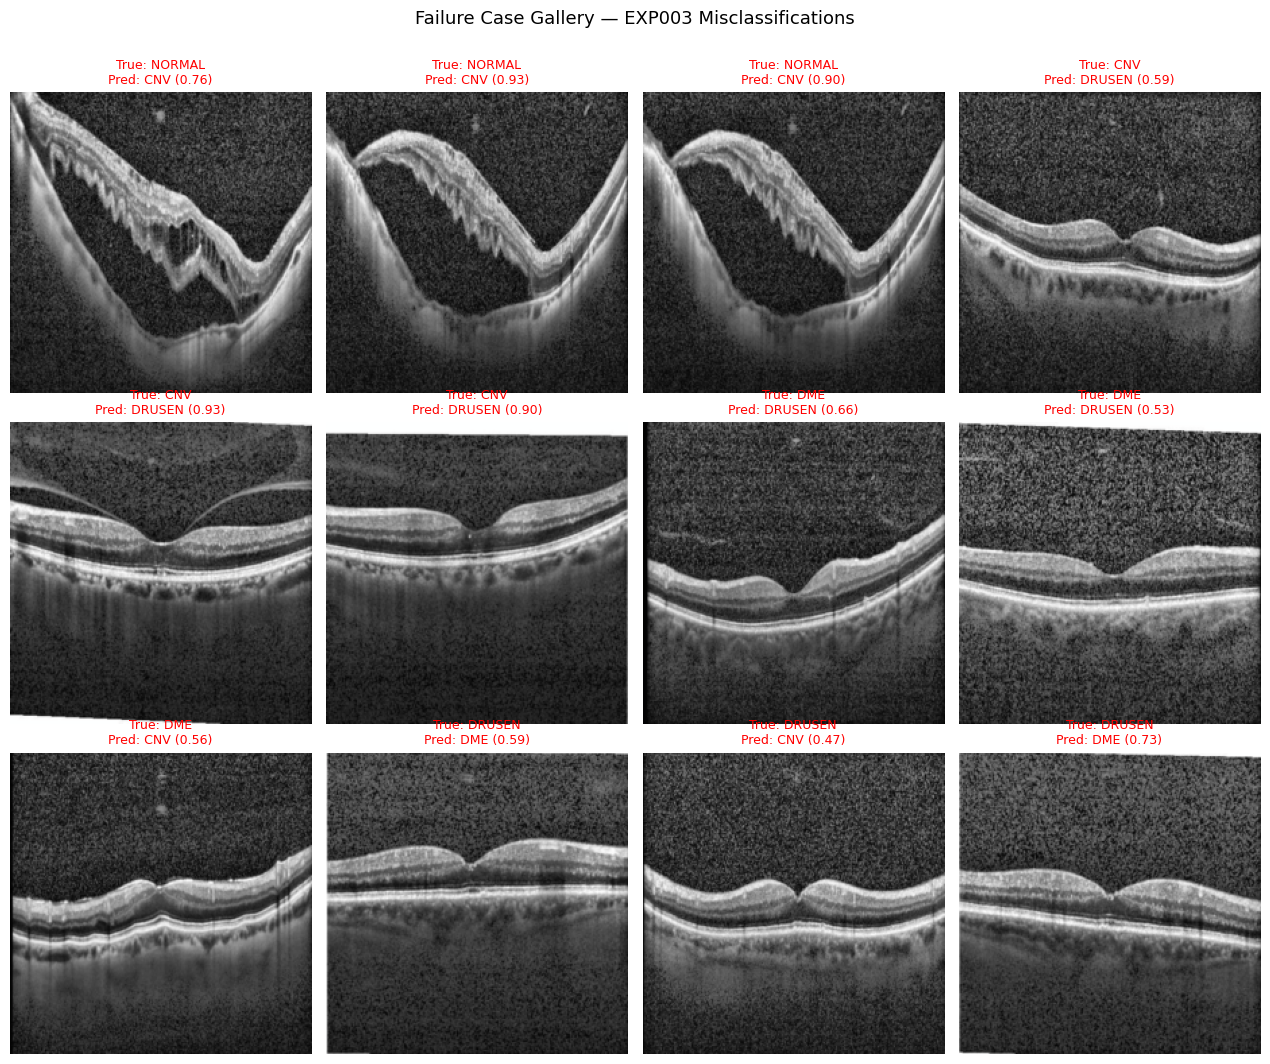

✓ Saved failure_cases.png  (12 cases shown)


In [71]:
#after robust b
# ==============================================================================
# 12. Failure Case Gallery (Misclassified Images)
# ==============================================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import torch

if 'CLASSES' not in locals():
    CLASSES = ['NORMAL', 'CNV', 'DME', 'DRUSEN']

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Collect up to 3 failure cases per class
failures = {i: [] for i in range(len(CLASSES))}
model_exp003.eval()

with torch.no_grad():
    for idx in range(len(test_ds)):
        img_t, true_label, *_ = test_ds[idx]
        if all(len(v) >= 3 for v in failures.values()):
            break
        if len(failures[true_label]) >= 3:
            continue
        logits = model_exp003(img_t.unsqueeze(0).to(device))
        probs  = torch.softmax(logits, dim=1)[0].cpu()
        pred   = probs.argmax().item()
        if pred != true_label:
            failures[true_label].append({
                'img_t':      img_t,
                'true_label': true_label,
                'pred_label': pred,
                'conf':       float(probs[pred]),
            })

# Plot
all_cases = [case for cases in failures.values() for case in cases]
n = len(all_cases)
if n == 0:
    print("No failure cases found in first pass — model may be very accurate.")
else:
    cols = 4
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.2, rows * 3.5))
    axes = np.array(axes).reshape(-1, cols) if rows > 1 else np.array([axes])
    axes_flat = axes.flatten()

    for ax in axes_flat:
        ax.axis('off')

    for i, case in enumerate(all_cases):
        img_np = case['img_t'].permute(1, 2, 0).numpy()
        img_np = (img_np * IMAGENET_STD + IMAGENET_MEAN).clip(0, 1)
        ax = axes_flat[i]
        ax.imshow(img_np, cmap='gray' if img_np.shape[2] == 1 else None)
        ax.set_title(
            f"True: {CLASSES[case['true_label']]}\n"
            f"Pred: {CLASSES[case['pred_label']]} ({case['conf']:.2f})",
            fontsize=9, color='red'
        )
        for spine in ax.spines.values():
            spine.set_edgecolor('red')
            spine.set_linewidth(2)
        ax.set_xticks([]); ax.set_yticks([])

    fig.suptitle('Failure Case Gallery — EXP003 Misclassifications', fontsize=13, y=1.01)
    fig.tight_layout()
    fig.savefig('failure_cases.png', dpi=200, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved failure_cases.png  ({n} cases shown)")

In [76]:
# ==============================================================================
# 13. Backup All Outputs to Google Drive
# ==============================================================================
import shutil, os

DRIVE_OUT = '/content/drive/MyDrive/TrustOCT_Results/notebook3_outputs'
os.makedirs(DRIVE_OUT, exist_ok=True)

files_to_backup = [
    'ablation_table.csv',
    'robustness_table.csv',
    'compute_analysis.csv',
    'layercam_gallery.png',
    'reliability_diagram.png',
    'failure_cases.png',
]

print("=== Backing up to Google Drive ===")
for fname in files_to_backup:
    if os.path.exists(fname):
        dst = os.path.join(DRIVE_OUT, fname)
        shutil.copy(fname, dst)
        size_kb = os.path.getsize(dst) / 1024
        print(f"  ✅ {fname}  →  {dst}  ({size_kb:.1f} KB)")
    else:
        print(f"  ❌ {fname}  NOT FOUND — skipped")

print(f"\n✓ Backup complete → {DRIVE_OUT}")

=== Backing up to Google Drive ===
  ✅ ablation_table.csv  →  /content/drive/MyDrive/TrustOCT_Results/notebook3_outputs/ablation_table.csv  (0.3 KB)
  ✅ robustness_table.csv  →  /content/drive/MyDrive/TrustOCT_Results/notebook3_outputs/robustness_table.csv  (0.4 KB)
  ✅ compute_analysis.csv  →  /content/drive/MyDrive/TrustOCT_Results/notebook3_outputs/compute_analysis.csv  (0.1 KB)
  ✅ layercam_gallery.png  →  /content/drive/MyDrive/TrustOCT_Results/notebook3_outputs/layercam_gallery.png  (1782.5 KB)
  ✅ reliability_diagram.png  →  /content/drive/MyDrive/TrustOCT_Results/notebook3_outputs/reliability_diagram.png  (104.1 KB)
  ✅ failure_cases.png  →  /content/drive/MyDrive/TrustOCT_Results/notebook3_outputs/failure_cases.png  (3175.3 KB)

✓ Backup complete → /content/drive/MyDrive/TrustOCT_Results/notebook3_outputs


In [75]:
import shutil, os

src = 'robustness_table.csv'
dst = '/content/drive/MyDrive/TrustOCT_Results/notebook3_outputs/robustness_table.csv'

if os.path.exists(src):
    shutil.copy(src, dst)
    print(f"✅ robustness_table.csv → {dst}")
else:
    print("❌ robustness_table.csv still not found — did the robustness cell complete?")

✅ robustness_table.csv → /content/drive/MyDrive/TrustOCT_Results/notebook3_outputs/robustness_table.csv


In [74]:
# ==============================================================================
# 10. Robustness Evaluation — COMPLETE SELF-CONTAINED CELL
# ==============================================================================
import time, numpy as np, pandas as pd
from sklearn.metrics import accuracy_score, f1_score
import torch, torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import shutil, os

if 'BATCH_SIZE' not in locals(): BATCH_SIZE = 32
if 'CLASSES'    not in locals(): CLASSES = ['NORMAL', 'CNV', 'DME', 'DRUSEN']
if 'device'     not in locals(): device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# ── Perturbation functions ───────────────────────────────────────────────────
def add_gaussian_noise(x, sev):
    s = [0.02, 0.05, 0.10][sev-1]
    return torch.clamp(x + torch.randn_like(x)*s, -3, 3)

def add_gaussian_blur(x, sev):
    k = [3, 5, 7][sev-1]; sig = k/6.0; C = x.shape[1]
    g = torch.exp(-((torch.arange(k,dtype=torch.float32)-k//2)**2)/(2*sig**2))
    g = (g/g.sum()).to(x.device)
    kh = g.view(1,1,1,k).repeat(C,1,1,1)
    kv = g.view(1,1,k,1).repeat(C,1,1,1)
    p = k//2
    return F.conv2d(F.conv2d(x,kh,padding=(0,p),groups=C),kv,padding=(p,0),groups=C)

def adjust_brightness(x, sev):
    d = [0.06, 0.12, 0.20][sev-1]
    m = torch.tensor(IMAGENET_MEAN,device=x.device).view(1,-1,1,1)
    s = torch.tensor(IMAGENET_STD, device=x.device).view(1,-1,1,1)
    return (torch.clamp(x*s+m+d,0,1)-m)/s

def adjust_contrast(x, sev):
    f = [0.9, 0.75, 0.6][sev-1]
    m = torch.tensor(IMAGENET_MEAN,device=x.device).view(1,-1,1,1)
    s = torch.tensor(IMAGENET_STD, device=x.device).view(1,-1,1,1)
    px = x*s+m; gm = px.mean(dim=[2,3],keepdim=True)
    return (torch.clamp((px-gm)*f+gm,0,1)-m)/s

PERTS = {
    'gaussian_noise':  (add_gaussian_noise,  False),
    'gaussian_blur':   (add_gaussian_blur,   False),
    'brightness':      (adjust_brightness,   True),
    'contrast':        (adjust_contrast,     True),
}

# ── Stratified subsample ─────────────────────────────────────────────────────
N_PER_CLASS = 200
rng = np.random.RandomState(42)
labels_arr = np.array([test_ds[i][1] for i in range(len(test_ds))])
subsample_idx = []
for c in range(len(CLASSES)):
    pos = np.where(labels_arr == c)[0]
    subsample_idx.extend(rng.choice(pos, size=min(N_PER_CLASS,len(pos)), replace=False).tolist())
subsample_idx = sorted(subsample_idx)

rob_loader = DataLoader(Subset(test_ds, subsample_idx),
                        batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
print(f"Robustness eval: {len(subsample_idx)} images × 4 perturbations × 3 severities = 12 passes\n")

# ── Evaluation loop ──────────────────────────────────────────────────────────
model_exp003.eval()
results, pass_n, total_passes = [], 0, len(PERTS)*3

for name, (fn, needs_norm) in PERTS.items():
    for sev in (1, 2, 3):
        pass_n += 1
        t0 = time.time()
        print(f"[{pass_n}/{total_passes}] {name} severity={sev}...", end=' ', flush=True)
        all_labels, all_preds = [], []
        with torch.no_grad():
            for batch in rob_loader:
                imgs, labels = batch[0].to(device), batch[1]
                imgs_p = fn(imgs, sev)
                preds  = model_exp003(imgs_p).argmax(dim=1).cpu().numpy()
                all_preds.append(preds)
                all_labels.append(labels.numpy())
        y_true = np.concatenate(all_labels)
        y_pred = np.concatenate(all_preds)
        acc = accuracy_score(y_true, y_pred)
        f1m = f1_score(y_true, y_pred, average='macro', zero_division=0)
        results.append({'perturbation': name, 'severity': sev,
                        'accuracy': round(acc,4), 'f1_macro': round(f1m,4)})
        print(f"acc={acc:.4f}  f1={f1m:.4f}  ({time.time()-t0:.1f}s)")

# ── Save & display ───────────────────────────────────────────────────────────
rob_df = pd.DataFrame(results)
rob_df.to_csv('robustness_table.csv', index=False)
display(rob_df)

# Backup to Drive immediately
dst = '/content/drive/MyDrive/TrustOCT_Results/notebook3_outputs/robustness_table.csv'
shutil.copy('robustness_table.csv', dst)
print(f"\n✅ Saved robustness_table.csv → {dst}")
print("\n🎉 ALL EVALUATIONS COMPLETE!")

Robustness eval: 800 images × 4 perturbations × 3 severities = 12 passes

[1/12] gaussian_noise severity=1... acc=0.9500  f1=0.9500  (9.0s)
[2/12] gaussian_noise severity=2... acc=0.9413  f1=0.9410  (7.1s)
[3/12] gaussian_noise severity=3... acc=0.9225  f1=0.9216  (8.9s)
[4/12] gaussian_blur severity=1... acc=0.9425  f1=0.9427  (8.9s)
[5/12] gaussian_blur severity=2... acc=0.9263  f1=0.9264  (7.8s)
[6/12] gaussian_blur severity=3... acc=0.9100  f1=0.9101  (8.9s)
[7/12] brightness severity=1... acc=0.9525  f1=0.9525  (7.4s)
[8/12] brightness severity=2... acc=0.9537  f1=0.9538  (9.1s)
[9/12] brightness severity=3... acc=0.9450  f1=0.9450  (6.9s)
[10/12] contrast severity=1... acc=0.9513  f1=0.9513  (9.2s)
[11/12] contrast severity=2... acc=0.9463  f1=0.9463  (7.4s)
[12/12] contrast severity=3... acc=0.9375  f1=0.9375  (9.3s)


,perturbation,severity,accuracy,f1_macro
0,gaussian_noise,1,0.9500,0.9500
1,gaussian_noise,2,0.9413,0.9410
2,gaussian_noise,3,0.9225,0.9216
3,gaussian_blur,1,0.9425,0.9427
4,gaussian_blur,2,0.9263,0.9264
5,gaussian_blur,3,0.9100,0.9101
6,brightness,1,0.9525,0.9525
7,brightness,2,0.9537,0.9538
8,brightness,3,0.9450,0.9450
9,contrast,1,0.9513,0.9513



✅ Saved robustness_table.csv → /content/drive/MyDrive/TrustOCT_Results/notebook3_outputs/robustness_table.csv

🎉 ALL EVALUATIONS COMPLETE!
